<a href="https://www.kaggle.com/code/omborse771924/credit-card-fraud-detection-2026-eda?scriptVersionId=336004752" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv')

In [3]:
df.head()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [4]:
df.tail()

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
19995,19996,41.40,Healthcare,Mastercard,OTP,POS,Android Phone,False,8.82,2,...,False,False,0,17.3,2,3,False,29.6,1,0
19996,19997,47.92,Online Retail,Visa,OTP,POS,Android Phone,False,45.81,1,...,False,False,0,9.0,4,0,False,29.2,1,0
19997,19998,10.25,Restaurants,Visa,3D Secure,In-App,Tablet,False,20.67,0,...,False,False,1,1.0,19,5,False,22.9,0,0
19998,19999,31.34,Travel,Visa,3D Secure,Online,Android Phone,False,22.94,2,...,False,False,0,8.8,2,1,False,27.9,0,0
19999,20000,47.70,Online Retail,Mastercard,Biometric,Online,iPhone,False,1.20,6,...,False,False,0,41.9,0,6,False,14.4,0,0


In [5]:
df.info


<bound method DataFrame.info of        transaction_id  amount_usd merchant_category   card_type  \
0                   1       42.86       Restaurants        Visa   
1                   2        4.75     Online Retail  Mastercard   
2                   3       77.18         Groceries  Mastercard   
3                   4        1.69         Streaming        Visa   
4                   5      261.68            Travel        Visa   
...               ...         ...               ...         ...   
19995           19996       41.40        Healthcare  Mastercard   
19996           19997       47.92     Online Retail        Visa   
19997           19998       10.25       Restaurants        Visa   
19998           19999       31.34            Travel        Visa   
19999           20000       47.70     Online Retail  Mastercard   

             auth_method channel    device_type  is_foreign_transaction  \
0                    OTP  Online  Android Phone                   False   
1            

In [6]:
df.describe

<bound method NDFrame.describe of        transaction_id  amount_usd merchant_category   card_type  \
0                   1       42.86       Restaurants        Visa   
1                   2        4.75     Online Retail  Mastercard   
2                   3       77.18         Groceries  Mastercard   
3                   4        1.69         Streaming        Visa   
4                   5      261.68            Travel        Visa   
...               ...         ...               ...         ...   
19995           19996       41.40        Healthcare  Mastercard   
19996           19997       47.92     Online Retail        Visa   
19997           19998       10.25       Restaurants        Visa   
19998           19999       31.34            Travel        Visa   
19999           20000       47.70     Online Retail  Mastercard   

             auth_method channel    device_type  is_foreign_transaction  \
0                    OTP  Online  Android Phone                   False   
1          

In [7]:
df.isnull

<bound method DataFrame.isnull of        transaction_id  amount_usd merchant_category   card_type  \
0                   1       42.86       Restaurants        Visa   
1                   2        4.75     Online Retail  Mastercard   
2                   3       77.18         Groceries  Mastercard   
3                   4        1.69         Streaming        Visa   
4                   5      261.68            Travel        Visa   
...               ...         ...               ...         ...   
19995           19996       41.40        Healthcare  Mastercard   
19996           19997       47.92     Online Retail        Visa   
19997           19998       10.25       Restaurants        Visa   
19998           19999       31.34            Travel        Visa   
19999           20000       47.70     Online Retail  Mastercard   

             auth_method channel    device_type  is_foreign_transaction  \
0                    OTP  Online  Android Phone                   False   
1          

In [8]:
df.isnull().sum()

transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
19995    False
19996    False
19997    False
19998    False
19999    False
Length: 20000, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['transaction_id', 'amount_usd', 'merchant_category', 'card_type',
       'auth_method', 'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='object')

## EDA

Dataset Shape : (20000, 26)

Data Types
transaction_id                    int64
amount_usd                      float64
merchant_category                object
card_type                        object
auth_method                      object
channel                          object
device_type                      object
is_foreign_transaction             bool
hours_since_last_txn            float64
txn_count_last_24h                int64
distance_from_home_km           float64
card_age_months                   int64
customer_age                      int64
account_balance_usd             float64
is_new_merchant                    bool
used_vpn                           bool
ip_country_mismatch                bool
billing_shipping_mismatch          bool
cvv_retry_count                   int64
velocity_score                  float64
time_of_day_hour                  int64
day_of_week                       int64
is_ai_generated_scam_attempt       bool
merchant_risk_score             float64


,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000,20000,20000,20000,20000,20000,20000.000000,20000.000000,...,20000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000,20000.000000,20000.000000,20000.000000
unique,NaN,NaN,12,5,5,5,8,2,NaN,NaN,...,2,2,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,Online Retail,Visa,3D Secure,Online,Android Phone,False,NaN,NaN,...,False,False,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN
freq,NaN,NaN,3416,8417,5554,6810,5503,18760,NaN,NaN,...,18834,19127,NaN,NaN,NaN,NaN,19625,NaN,NaN,NaN
mean,10000.500000,132.424597,NaN,NaN,NaN,NaN,NaN,NaN,8.950827,3.191650,...,NaN,NaN,0.181300,19.807735,11.533650,2.998750,NaN,37.400390,0.281250,0.016950
std,5773.647028,256.963666,NaN,NaN,NaN,NaN,NaN,NaN,8.838745,1.779544,...,NaN,NaN,0.422302,12.366301,6.925335,2.004956,NaN,17.061415,0.529209,0.129087
min,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,0.000000,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,NaN,NaN,NaN,NaN,NaN,NaN,2.590000,2.000000,...,NaN,NaN,0.000000,10.700000,6.000000,1.000000,NaN,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,NaN,NaN,NaN,NaN,NaN,NaN,6.210000,3.000000,...,NaN,NaN,0.000000,18.800000,12.000000,3.000000,NaN,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,NaN,NaN,NaN,NaN,NaN,NaN,12.432500,4.000000,...,NaN,NaN,0.000000,27.600000,18.000000,5.000000,NaN,47.300000,0.000000,0.000000


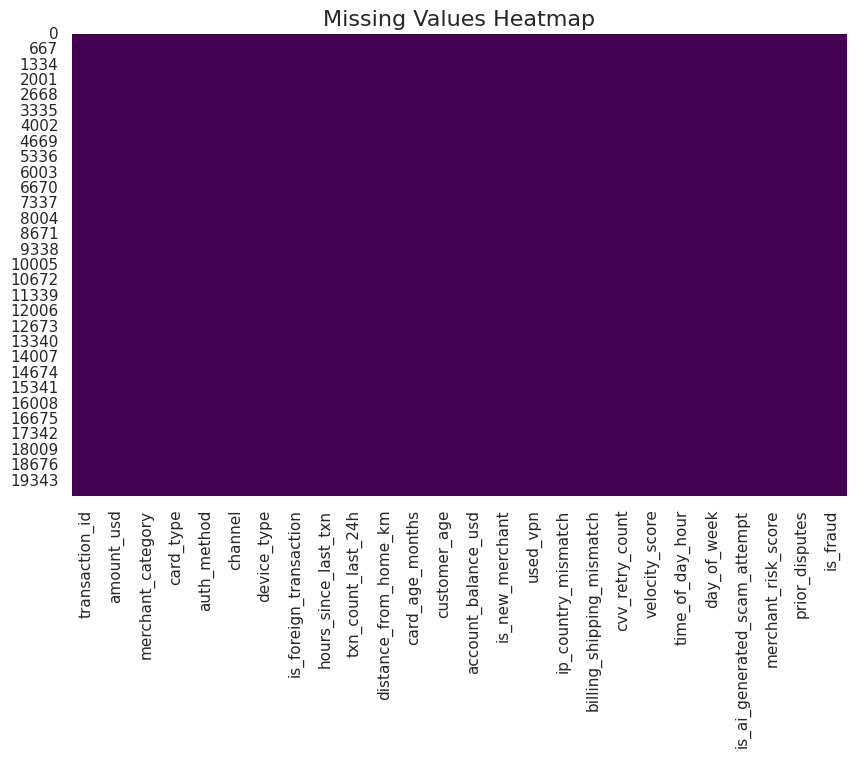

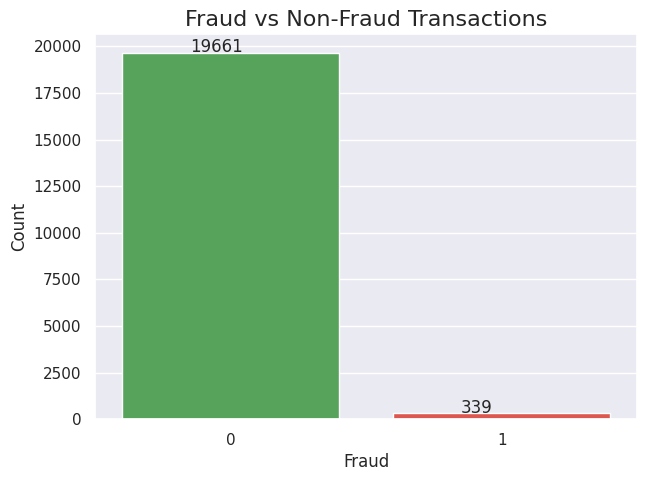

Numerical Columns
Index(['transaction_id', 'amount_usd', 'hours_since_last_txn',
       'txn_count_last_24h', 'distance_from_home_km', 'card_age_months',
       'customer_age', 'account_balance_usd', 'cvv_retry_count',
       'velocity_score', 'time_of_day_hour', 'day_of_week',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='object')


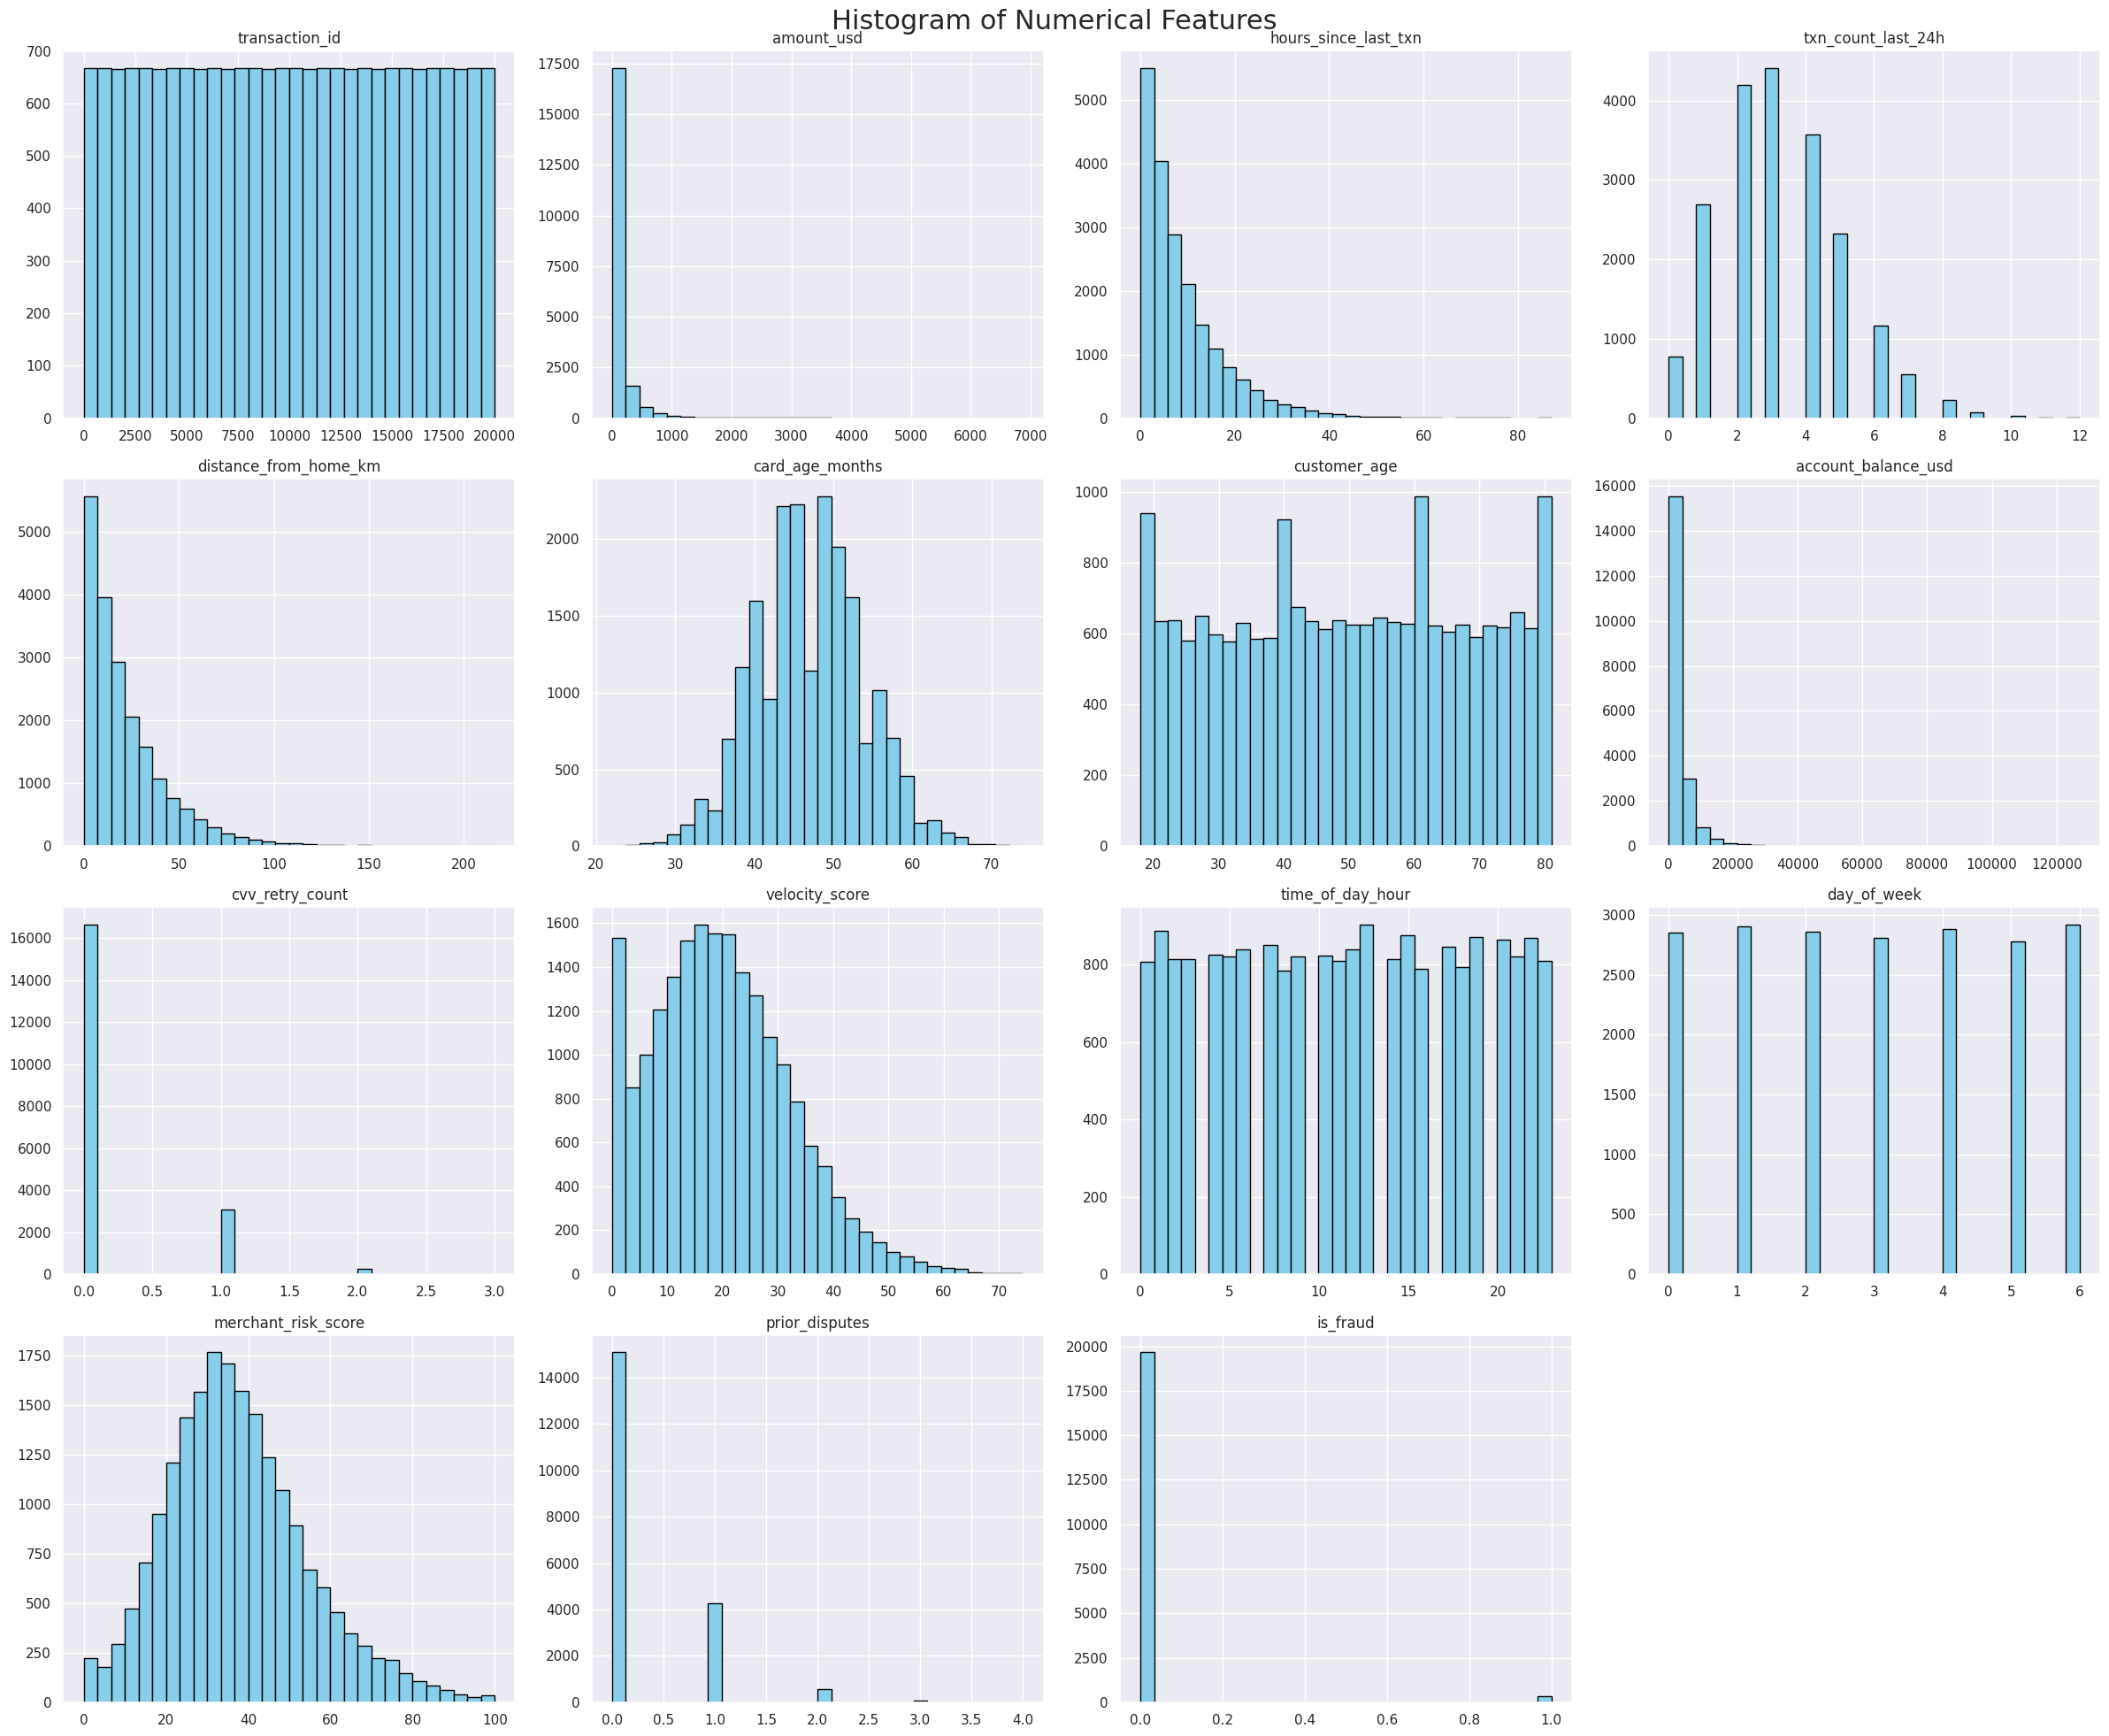

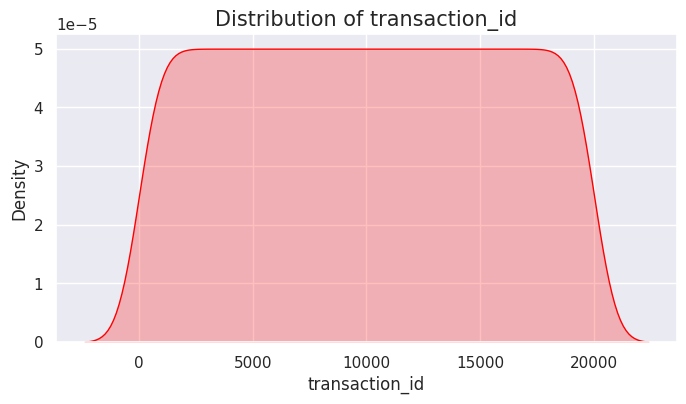

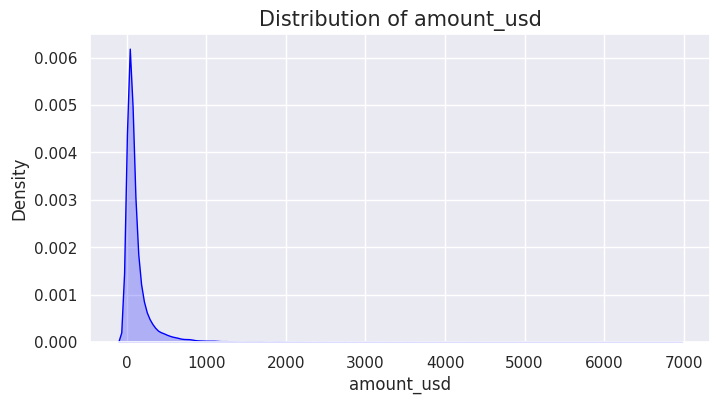

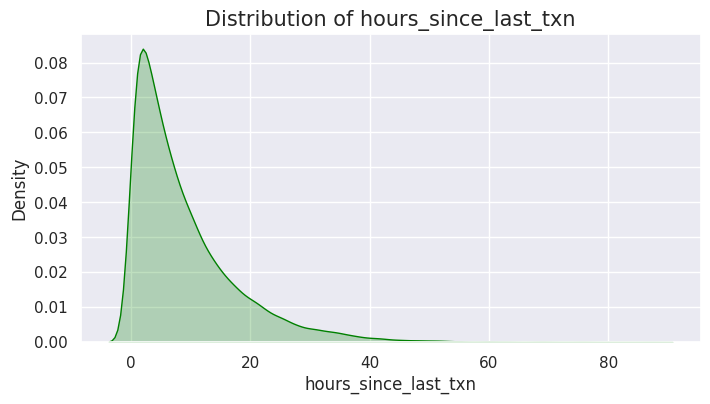

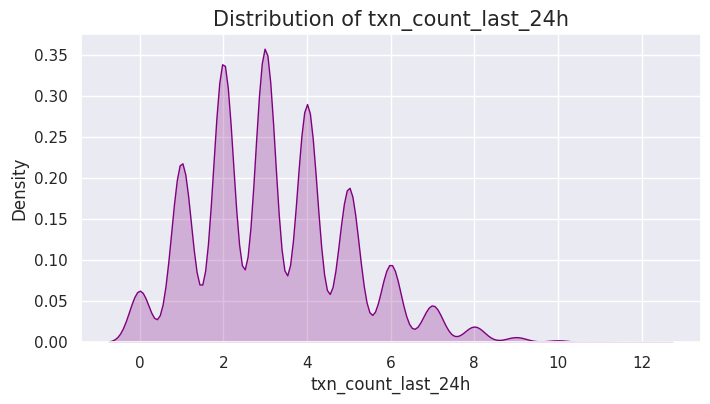

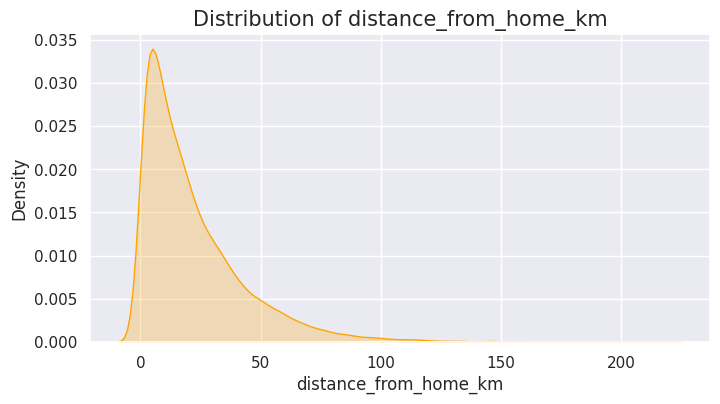

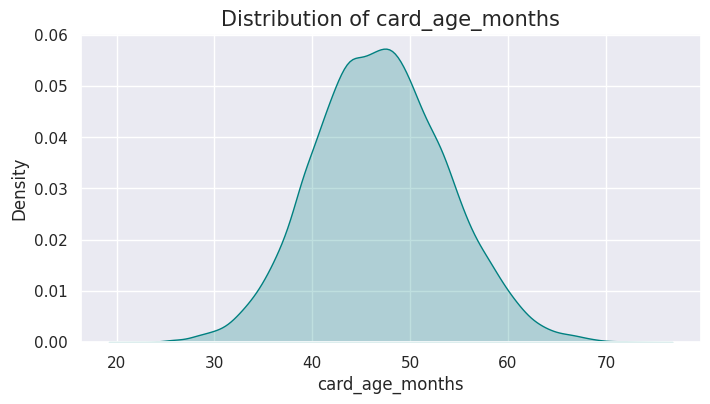

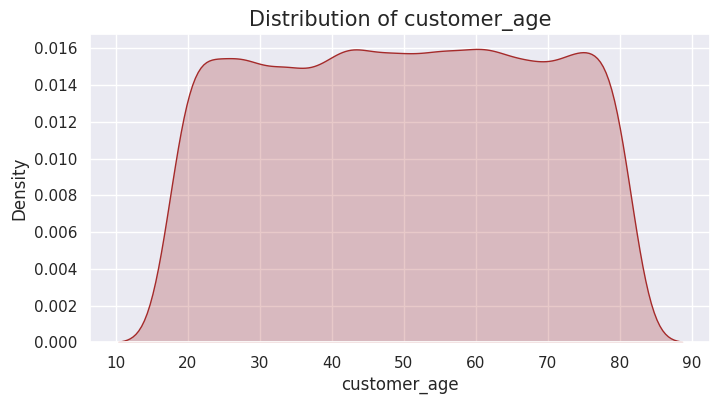

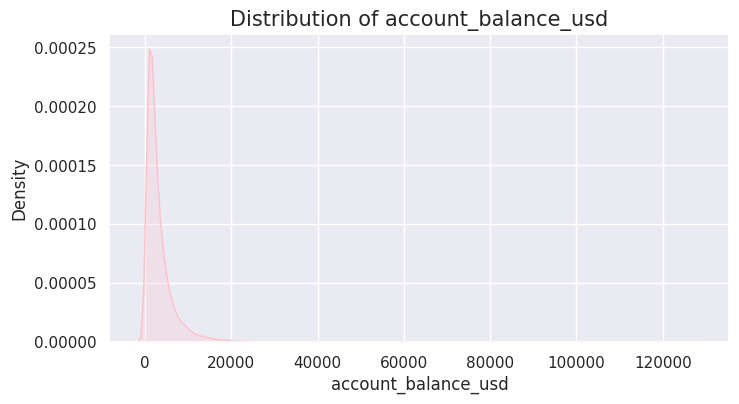

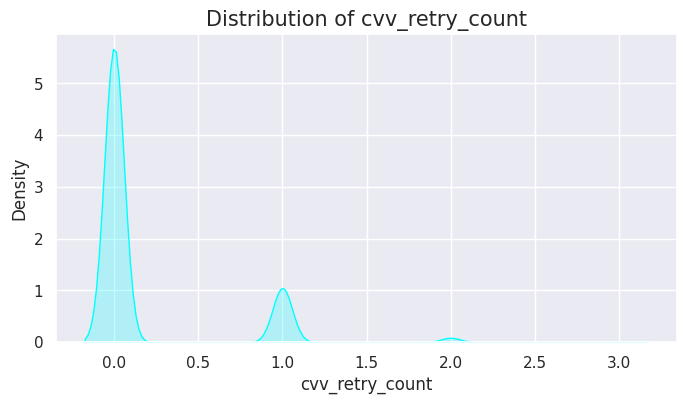

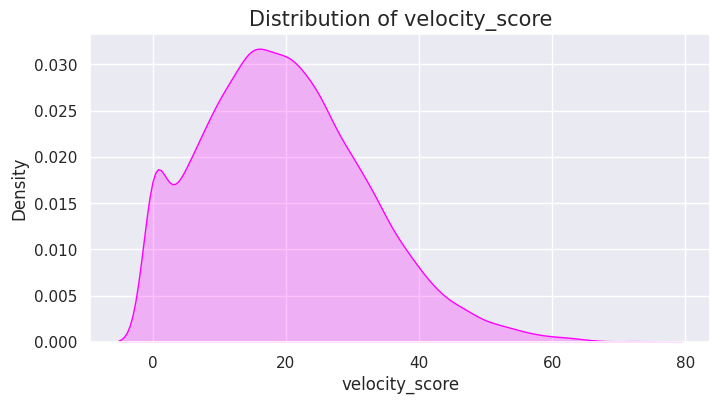

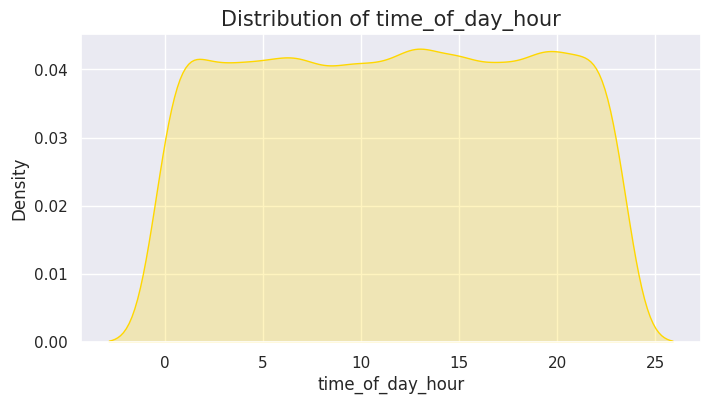

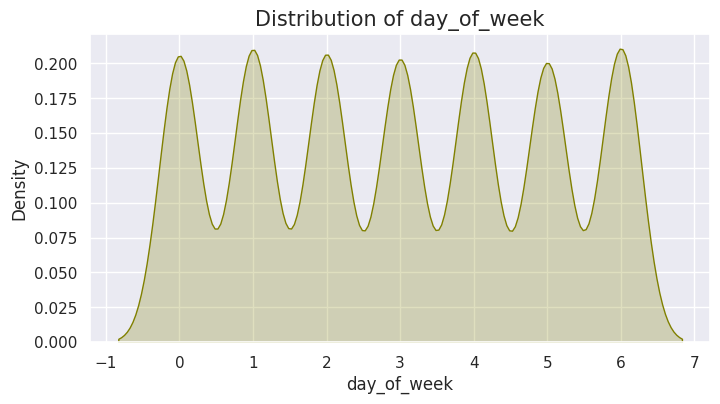

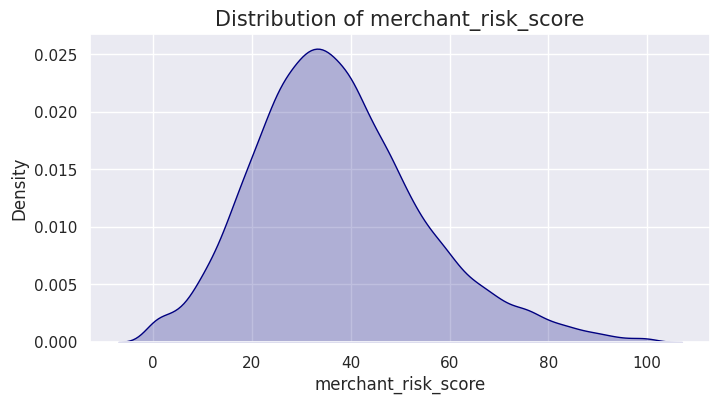

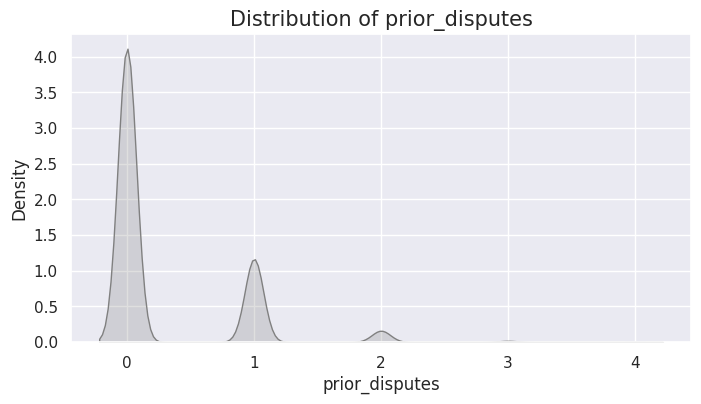

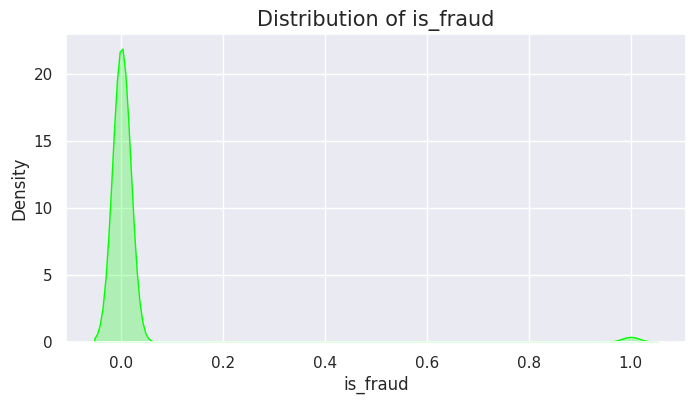

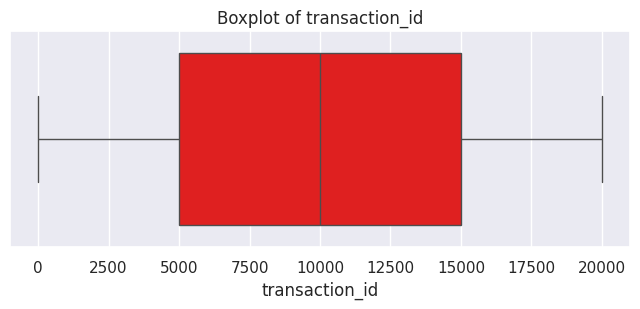

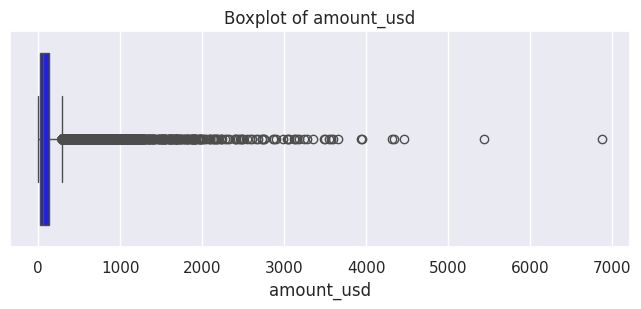

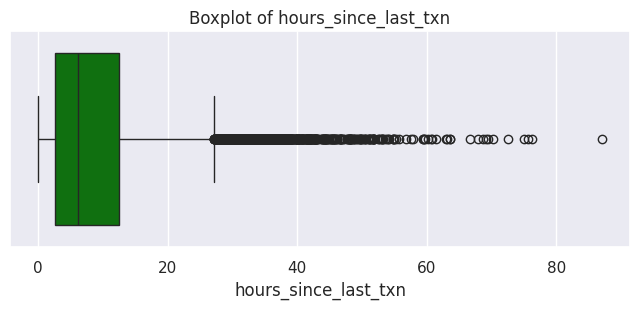

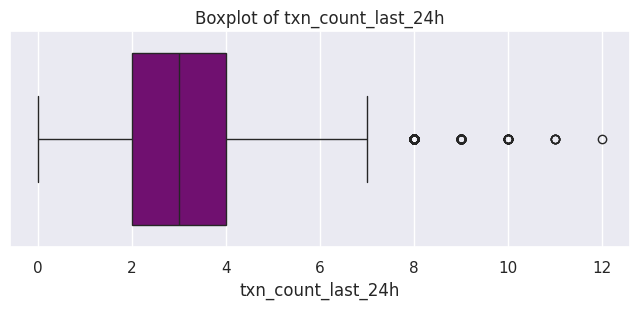

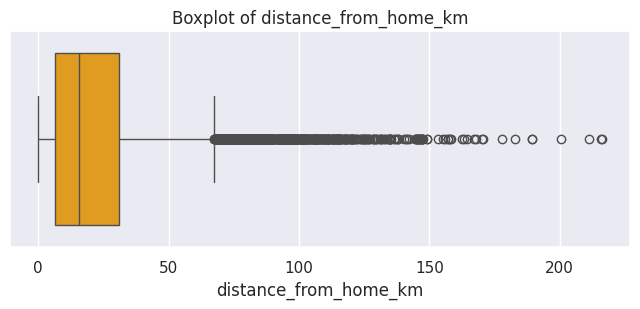

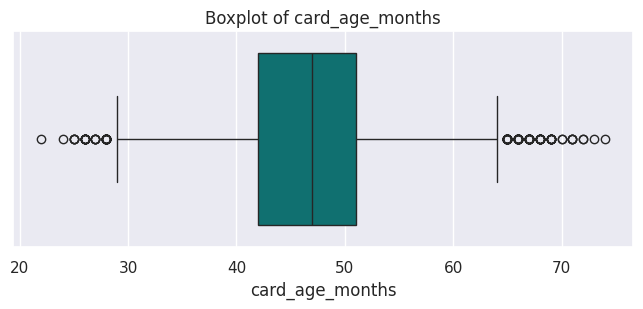

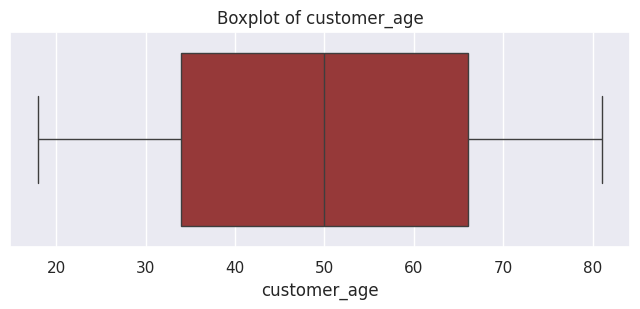

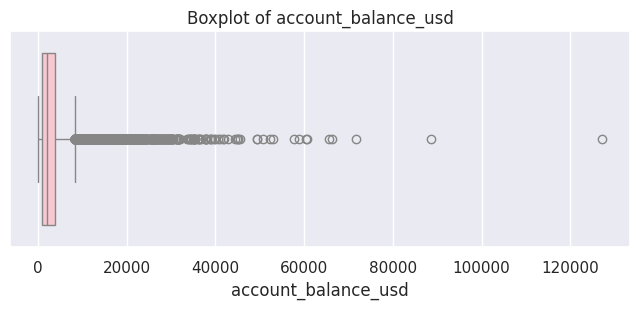

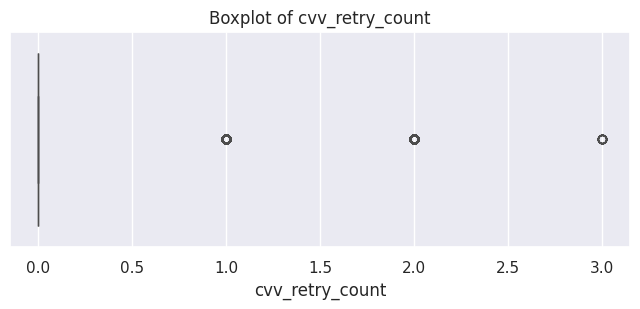

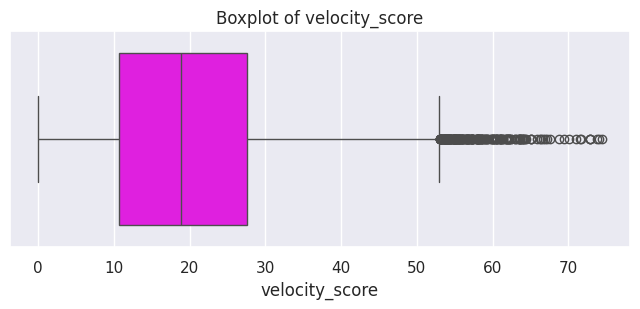

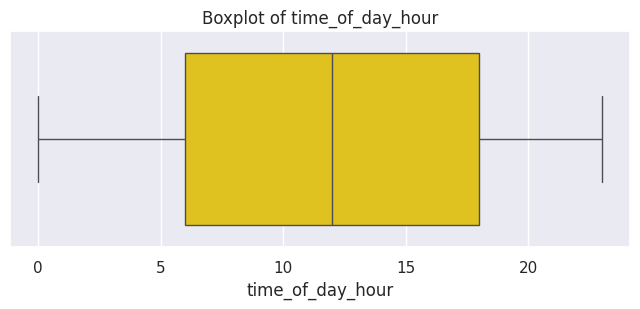

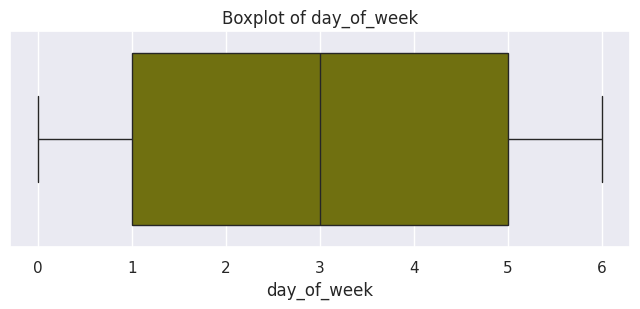

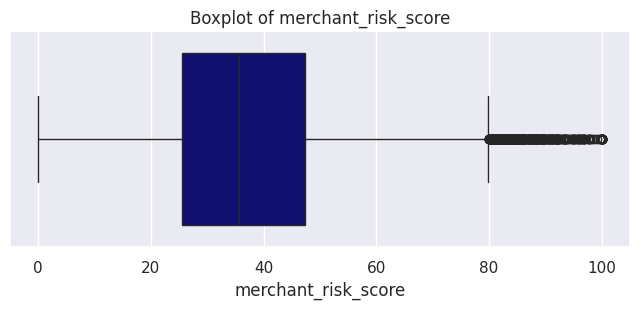

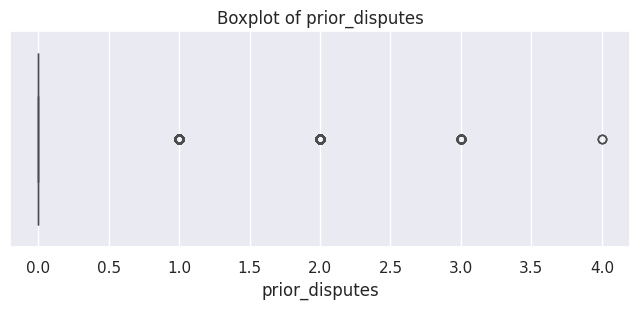

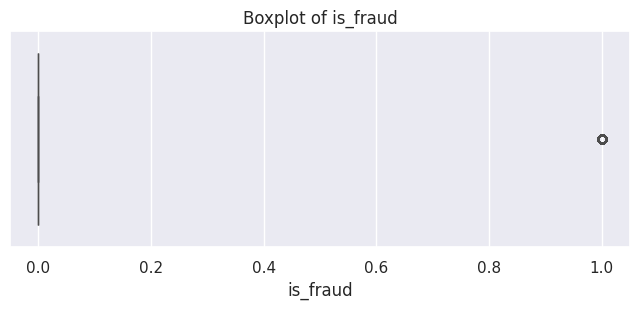

Index(['merchant_category', 'card_type', 'auth_method', 'channel',
       'device_type'],
      dtype='object')


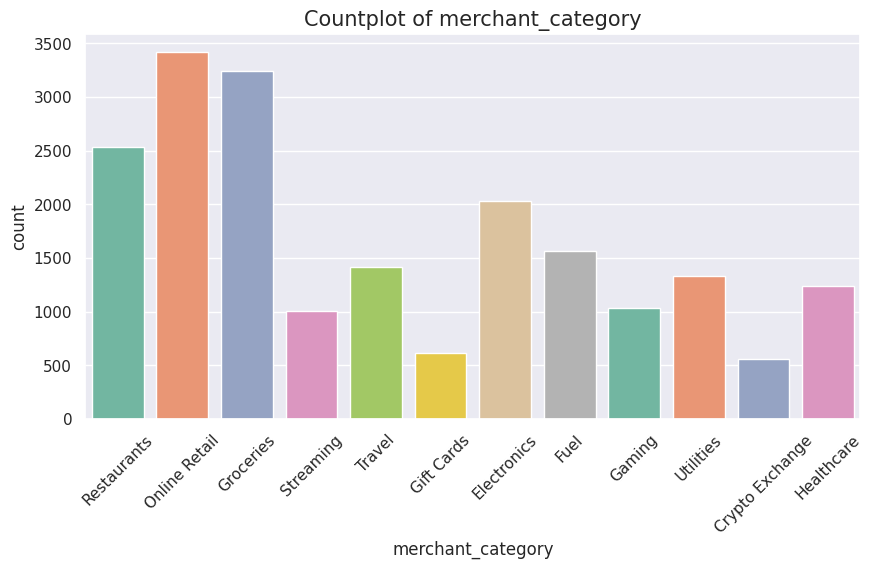

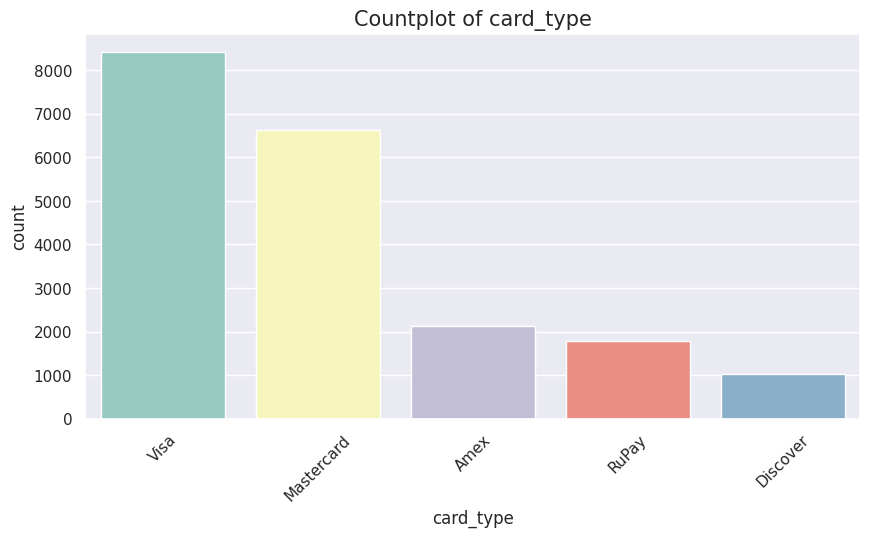

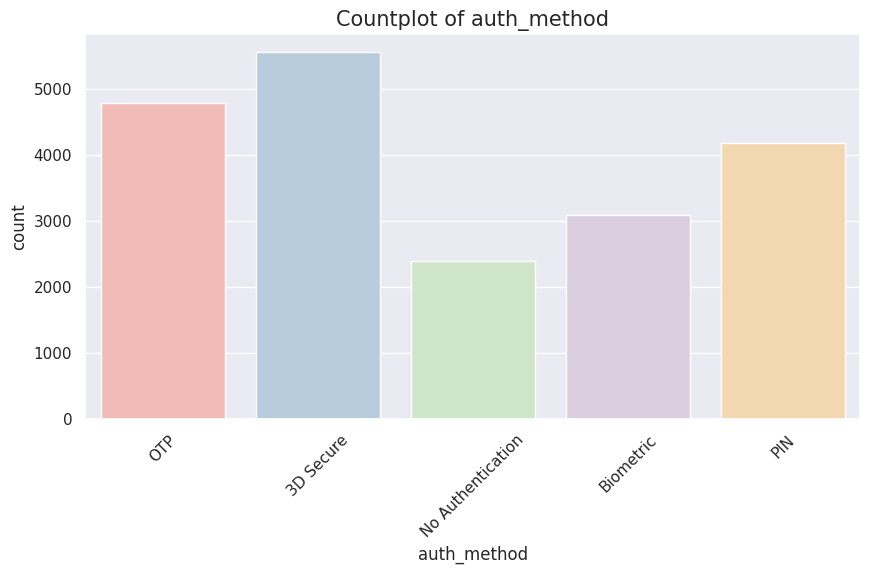

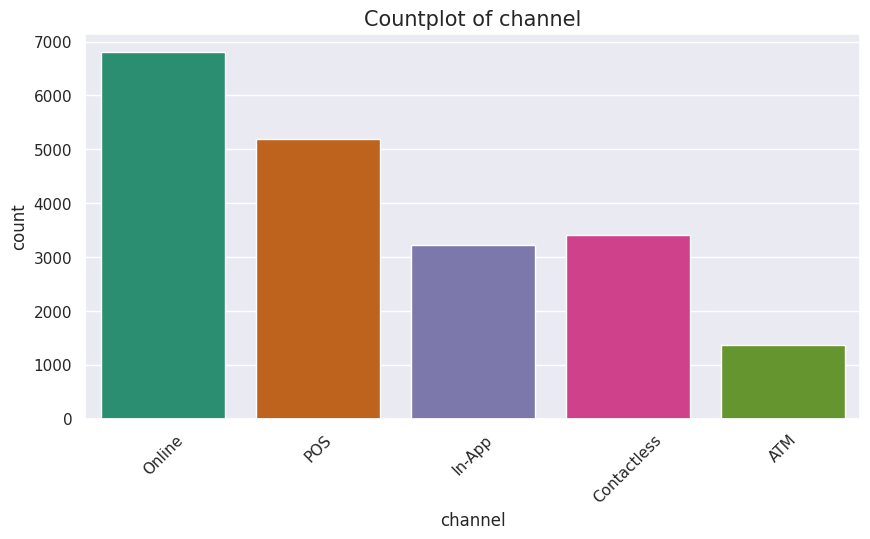

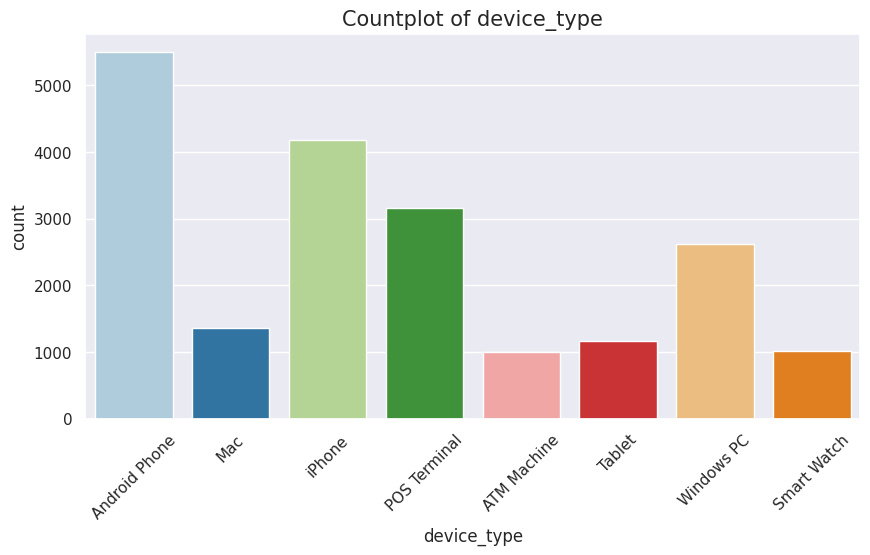

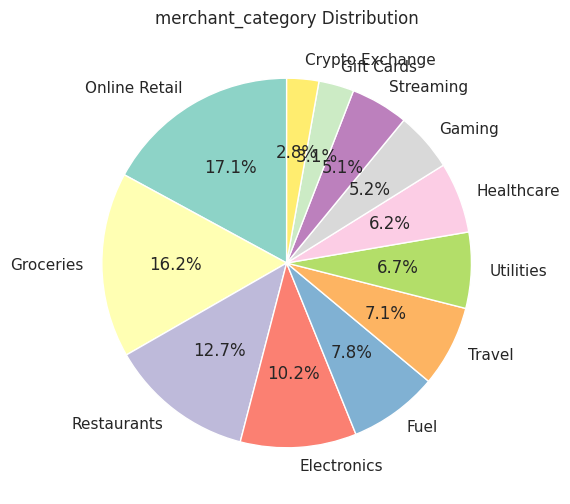

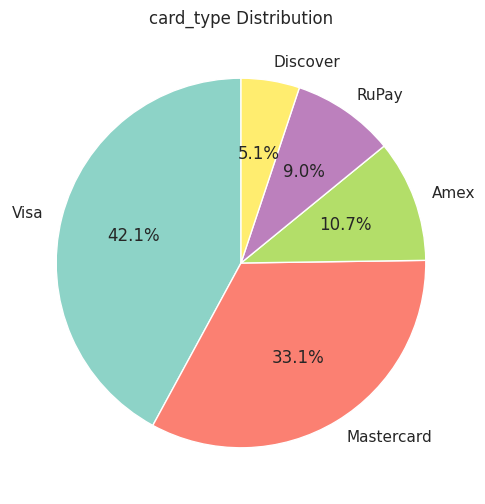

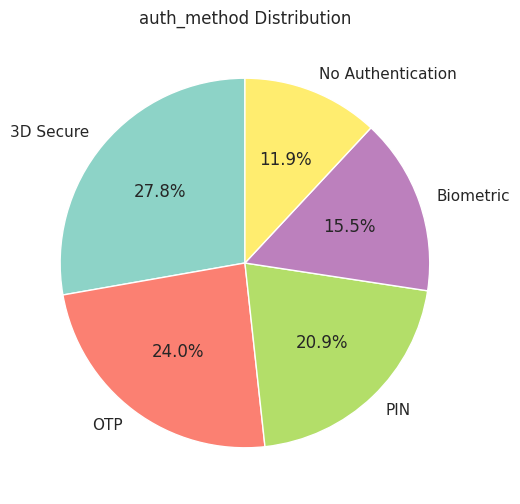

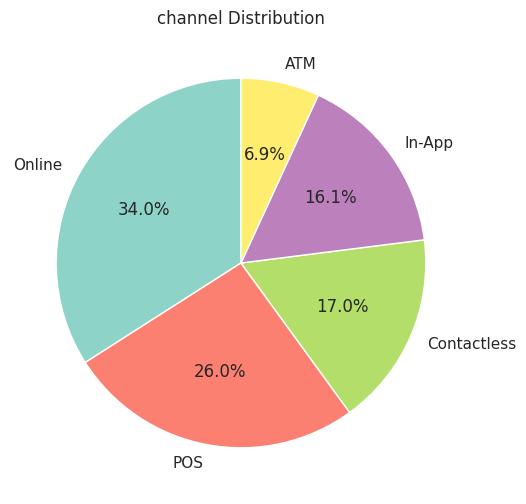

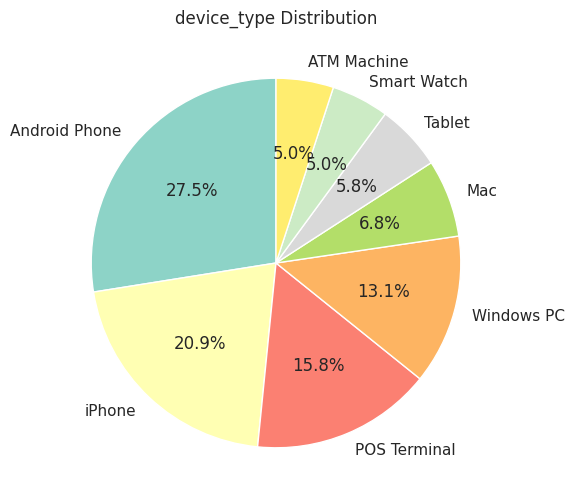

In [12]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.0)

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("="*70)
print("Dataset Shape :", df.shape)
print("="*70)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("\nStatistical Summary")
display(df.describe(include='all'))

# ==========================================================
# DATASET OVERVIEW
# ==========================================================

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")
plt.title("Missing Values Heatmap",fontsize=16)
plt.show()

# ==========================================================
# TARGET VARIABLE
# ==========================================================

plt.figure(figsize=(7,5))

colors=["#4CAF50","#F44336"]

sns.countplot(x="is_fraud",
              data=df,
              palette=colors)

plt.title("Fraud vs Non-Fraud Transactions",fontsize=16)
plt.xlabel("Fraud")
plt.ylabel("Count")

for i in plt.gca().patches:
    plt.text(i.get_x()+0.25,
             i.get_height()+20,
             str(int(i.get_height())),
             fontsize=12)

plt.show()

# ==========================================================
# NUMERICAL FEATURES
# ==========================================================

numeric_cols=df.select_dtypes(include=np.number).columns

print("Numerical Columns")
print(numeric_cols)

# ==========================================================
# HISTOGRAMS
# ==========================================================

df[numeric_cols].hist(figsize=(24,20),
                      bins=30,
                      color="skyblue",
                      edgecolor="black")

plt.suptitle("Histogram of Numerical Features",
             fontsize=22)

plt.tight_layout()
plt.show()

# ==========================================================
# KDE DISTRIBUTION
# ==========================================================

colors=[
'red','blue','green','purple','orange',
'teal','brown','pink','cyan','magenta',
'gold','olive','navy','gray','lime',
'coral','darkred','indigo','black','maroon'
]

for i,col in enumerate(numeric_cols):

    plt.figure(figsize=(8,4))

    sns.kdeplot(df[col],
                shade=True,
                color=colors[i%len(colors)])

    plt.title(f"Distribution of {col}",fontsize=15)

    plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

for i,col in enumerate(numeric_cols):

    plt.figure(figsize=(8,2.8))

    sns.boxplot(x=df[col],
                color=colors[i%len(colors)])

    plt.title(f"Boxplot of {col}")

    plt.show()

# ==========================================================
# CATEGORICAL FEATURES
# ==========================================================

categorical_cols=df.select_dtypes(include='object').columns

print(categorical_cols)

# ==========================================================
# COUNTPLOTS
# ==========================================================

palette_list=[
"Set2",
"Set3",
"Pastel1",
"Dark2",
"Paired",
"Accent",
"husl",
"tab10"
]

for i,col in enumerate(categorical_cols):

    plt.figure(figsize=(10,5))

    sns.countplot(data=df,
                  x=col,
                  palette=palette_list[i%len(palette_list)])

    plt.title(f"Countplot of {col}",
              fontsize=15)

    plt.xticks(rotation=45)

    plt.show()

# ==========================================================
# PIE CHARTS FOR CATEGORICAL FEATURES
# ==========================================================

for col in categorical_cols:

    plt.figure(figsize=(6,6))

    df[col].value_counts().plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        cmap="Set3"
    )

    plt.ylabel("")

    plt.title(f"{col} Distribution")

    plt.show()

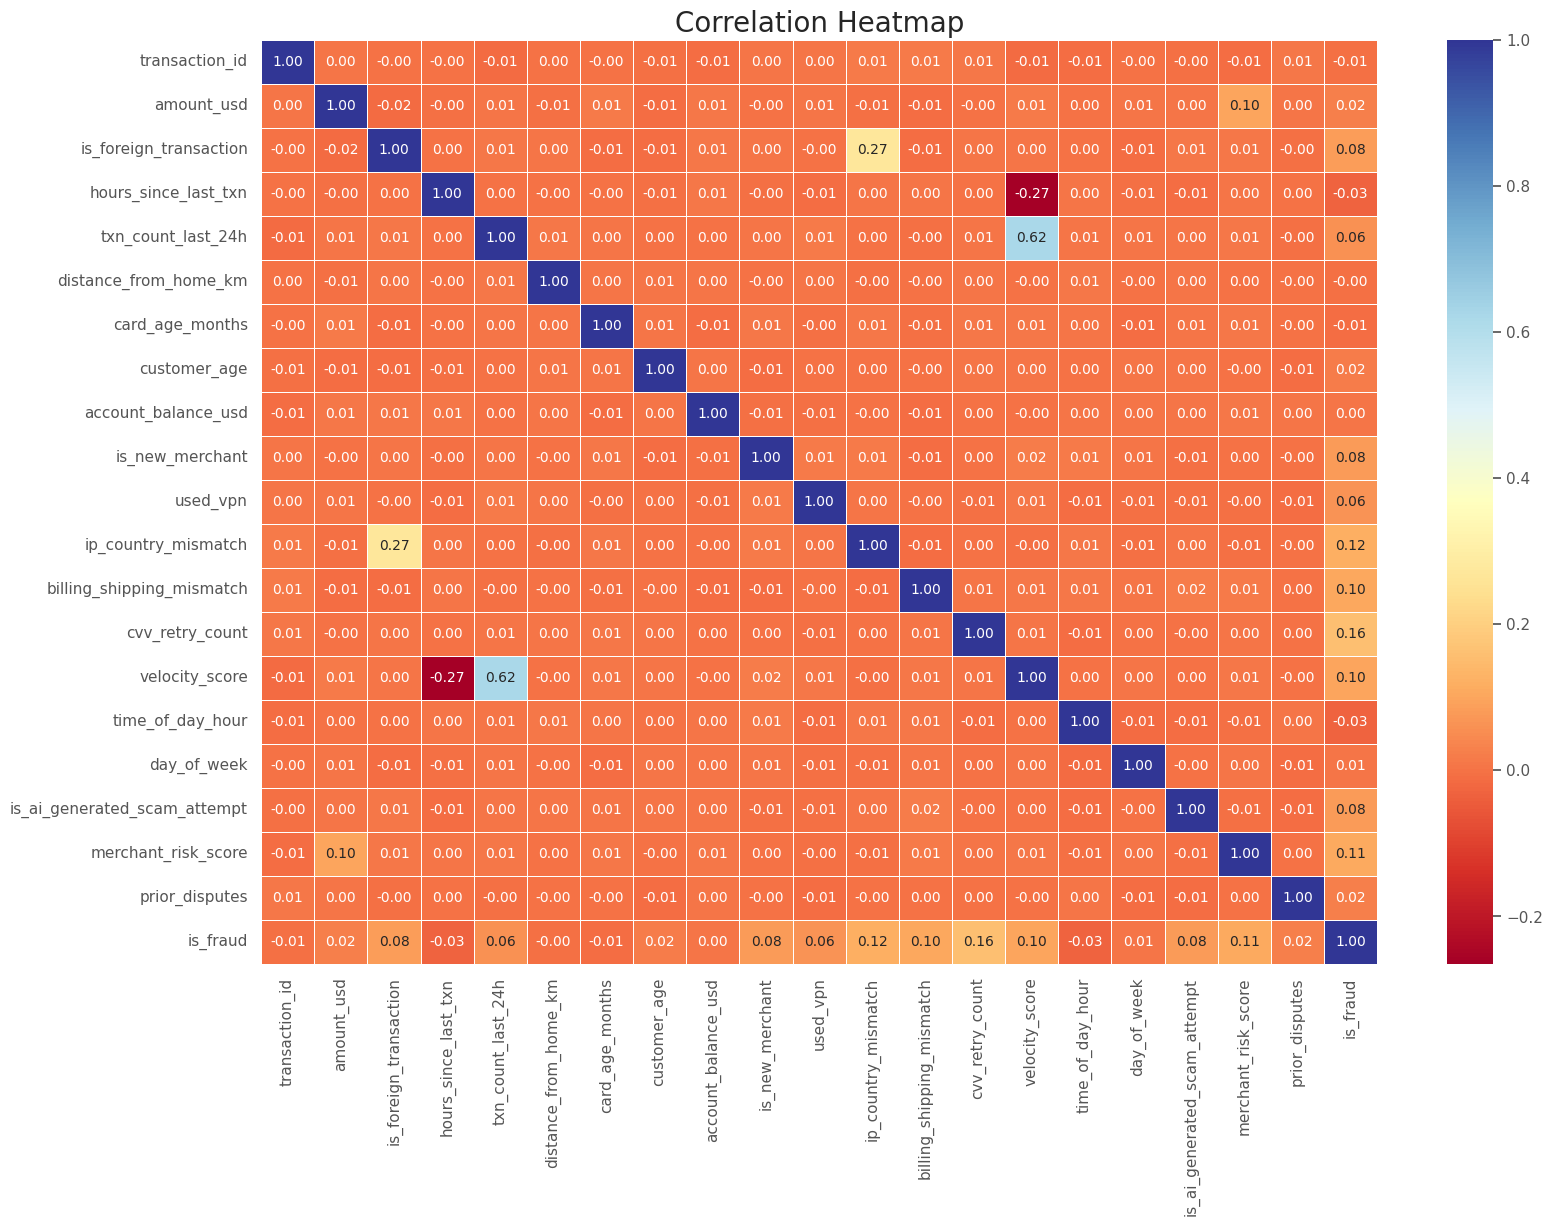

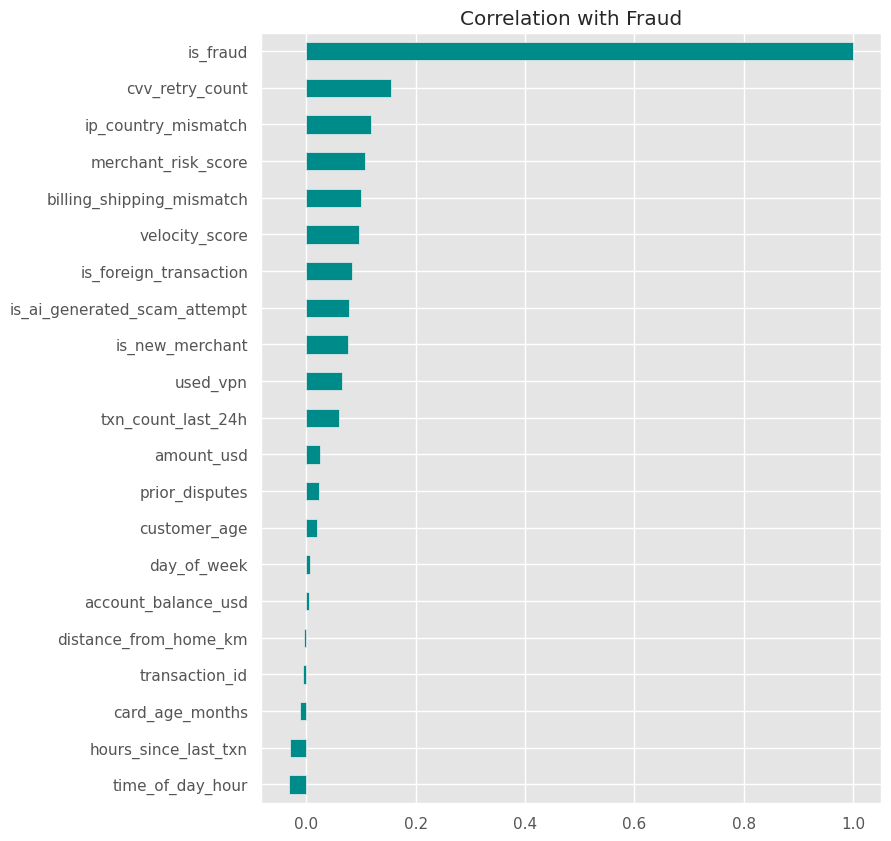

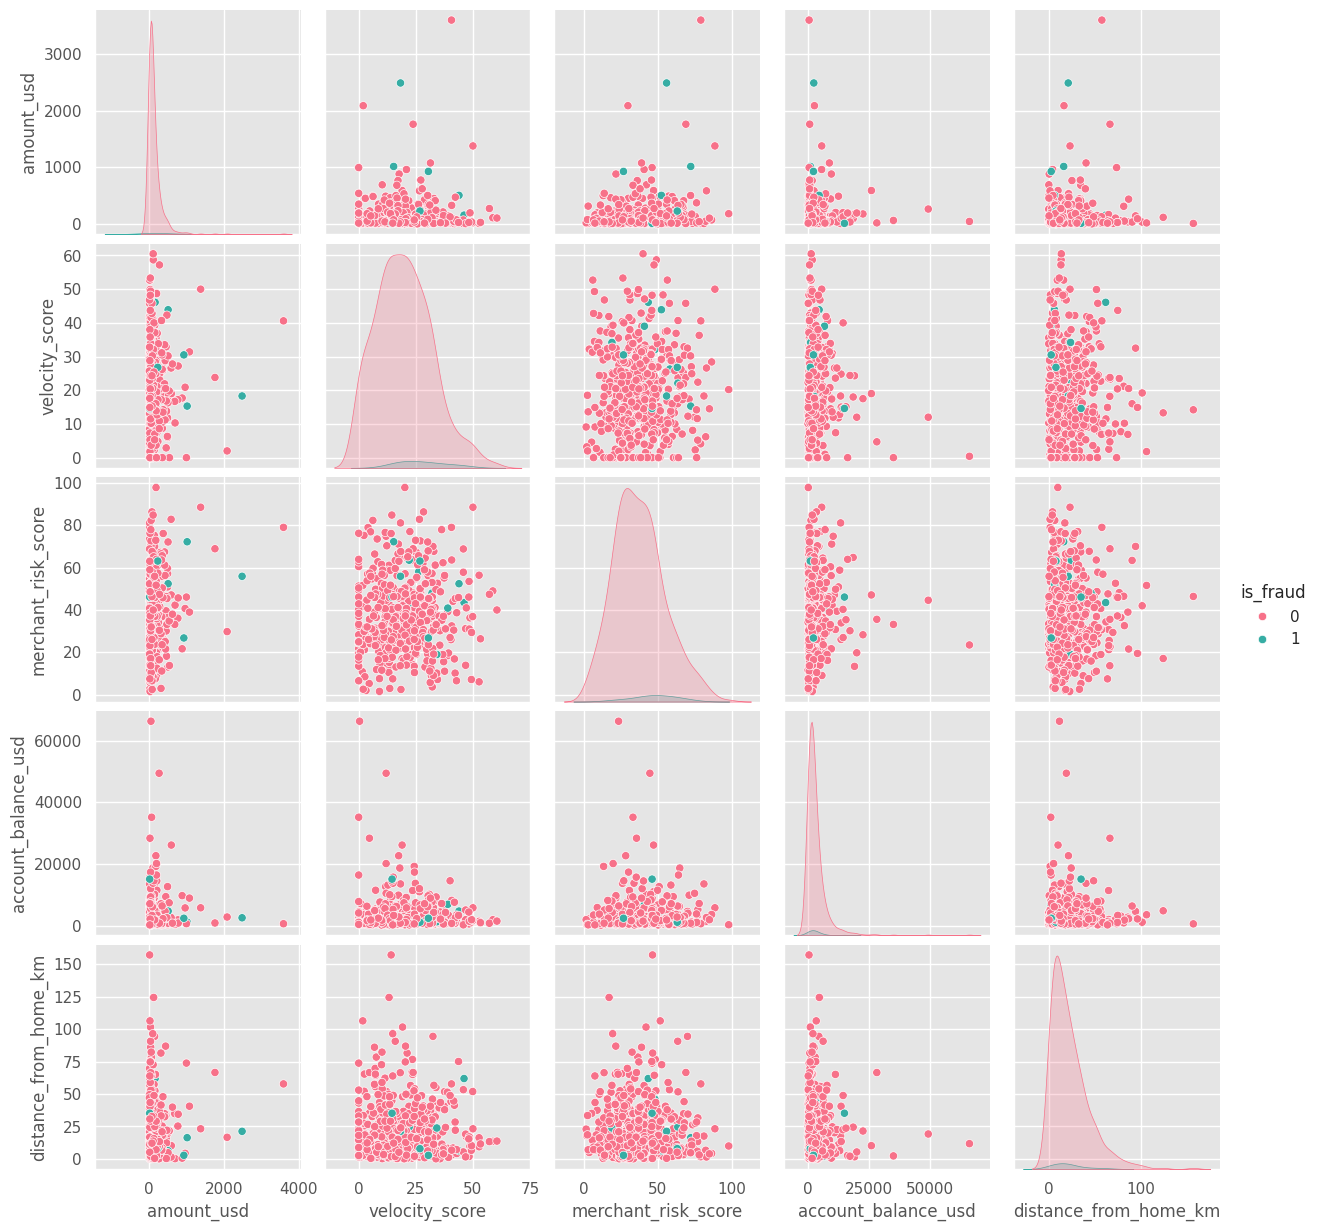

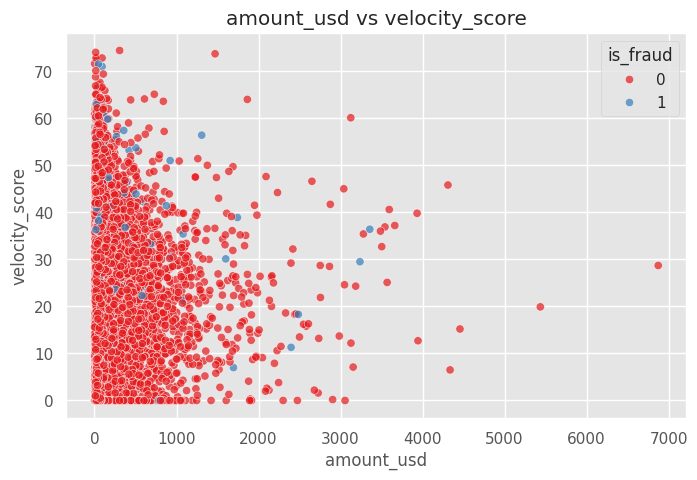

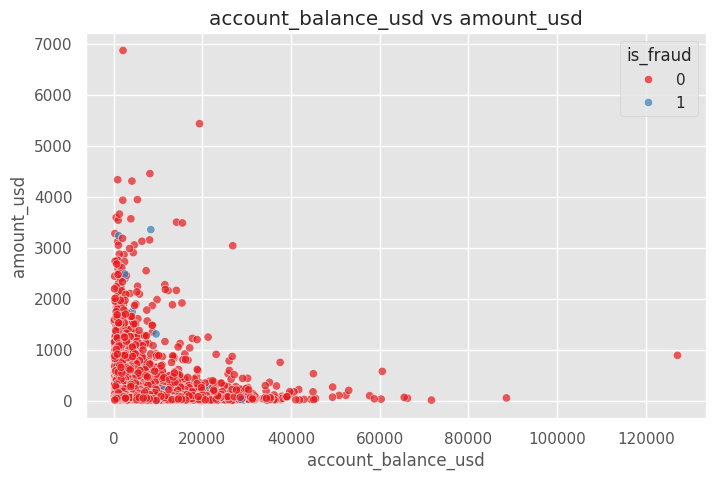

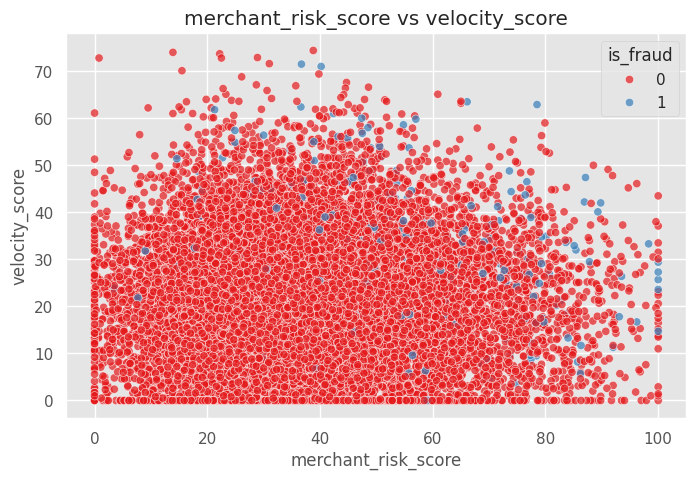

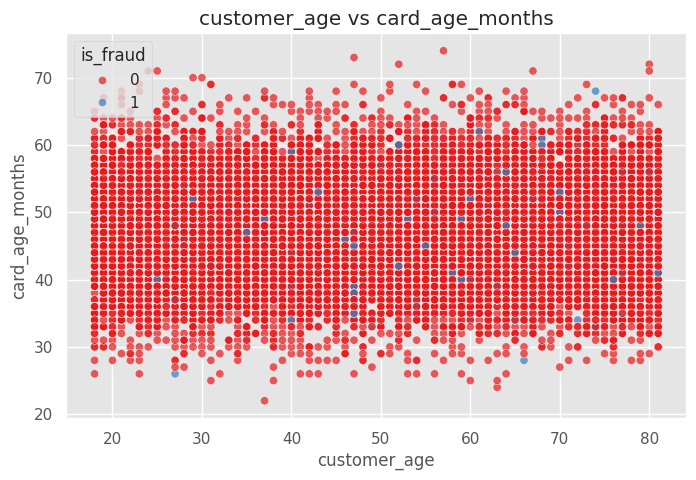

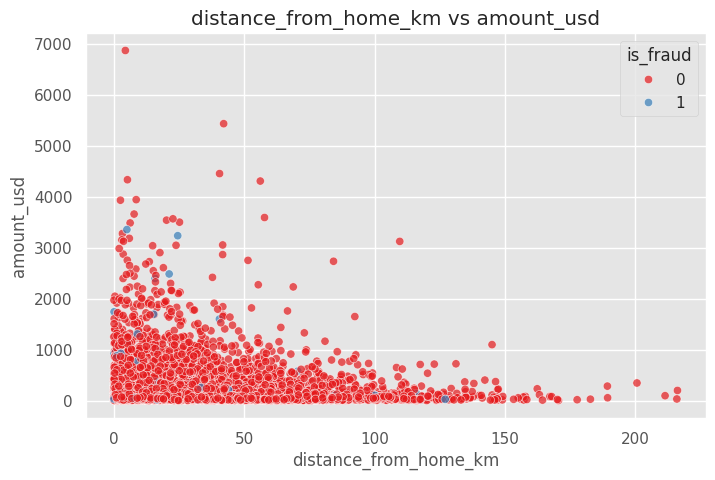

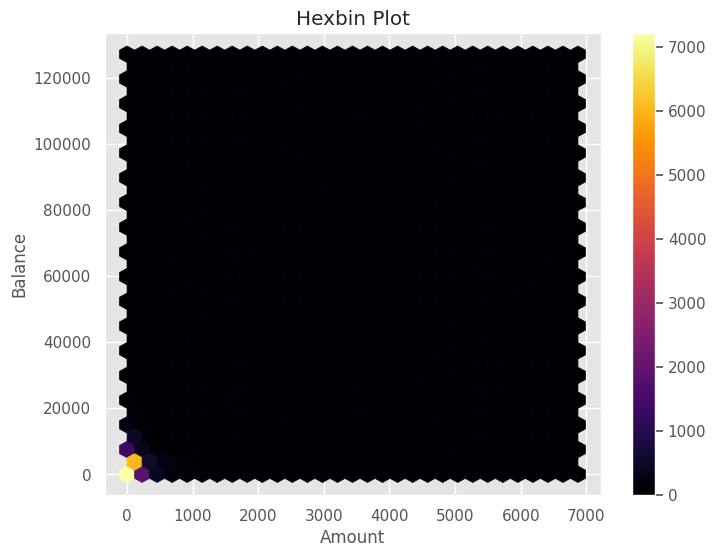

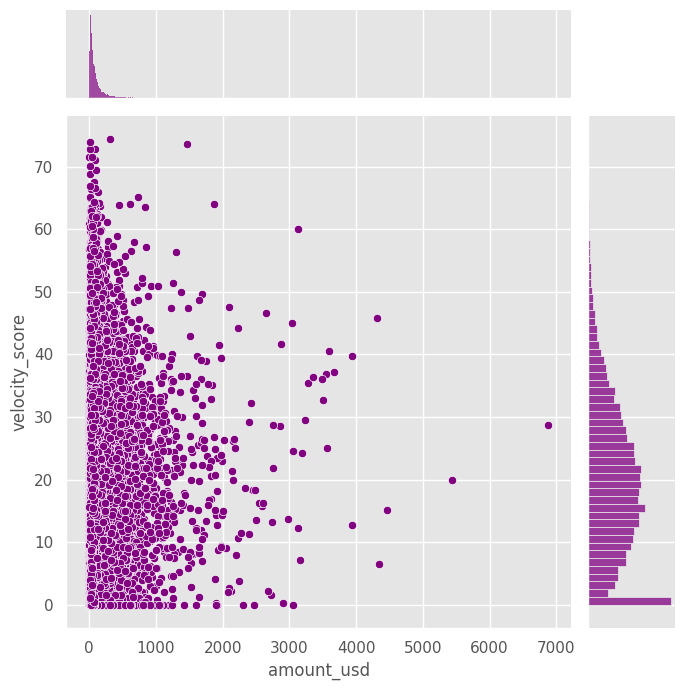

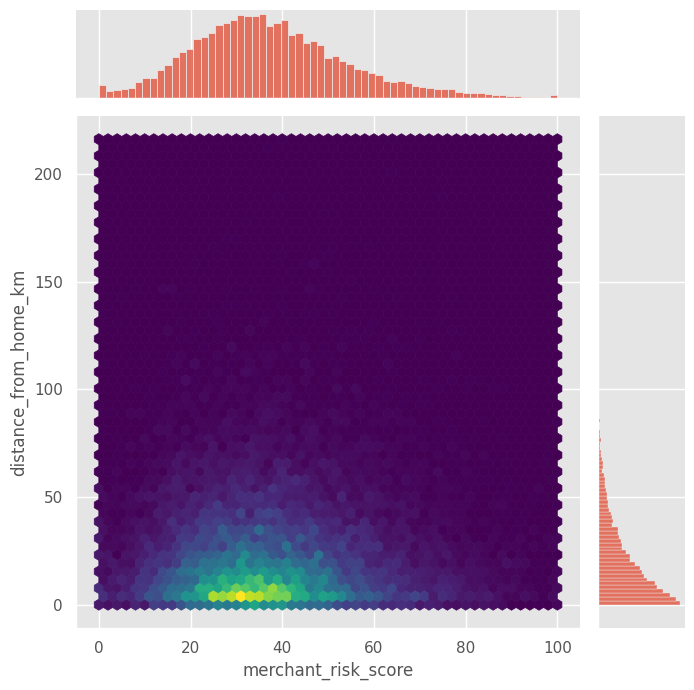

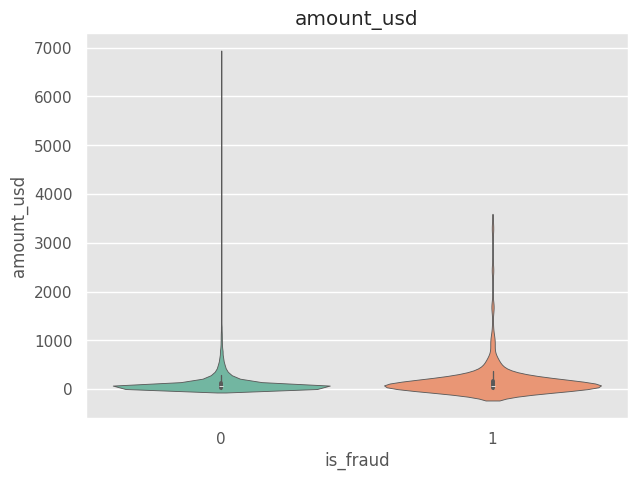

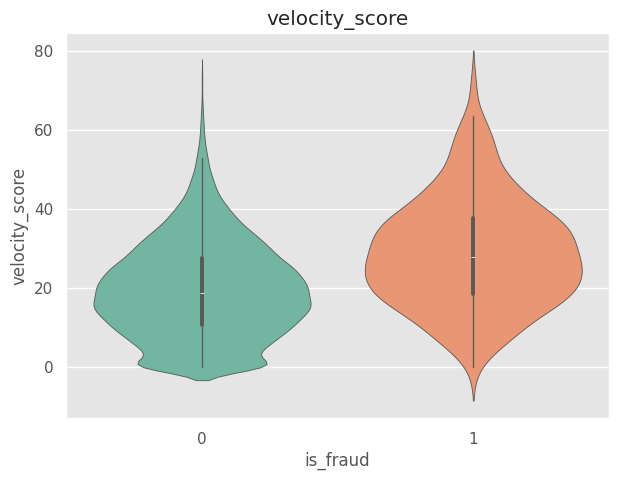

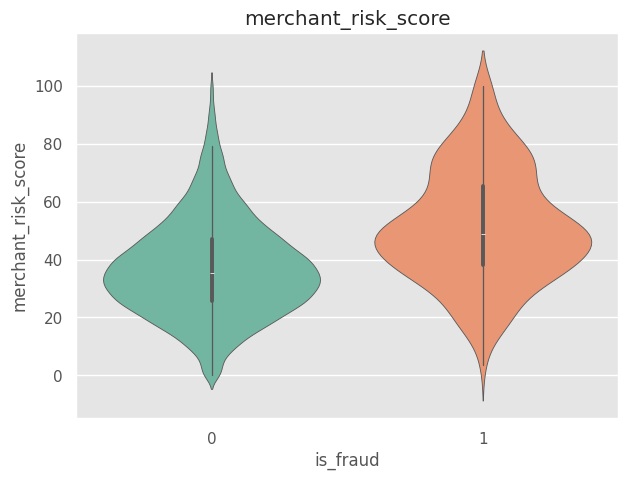

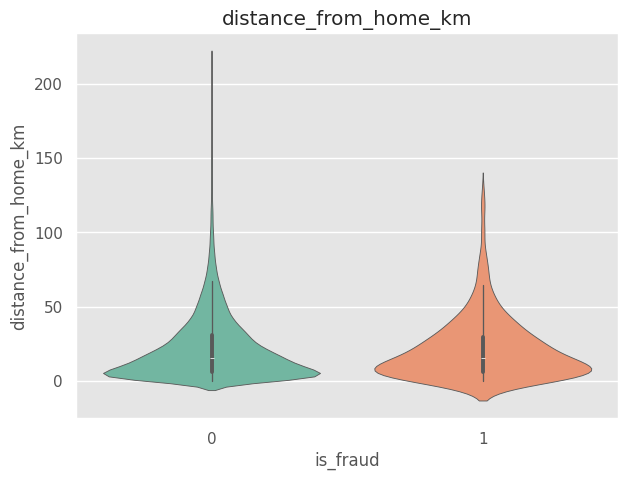

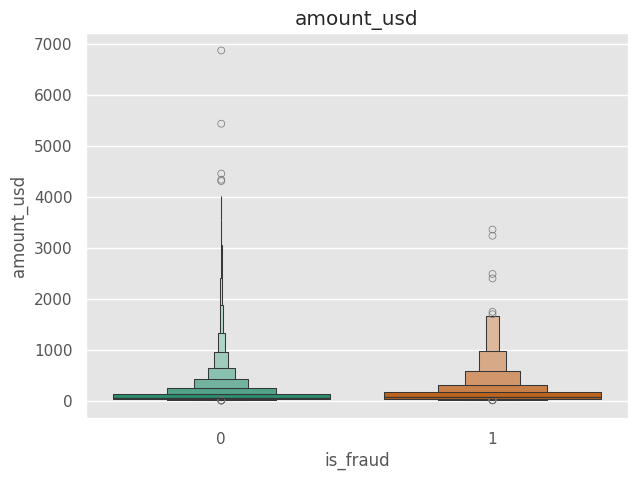

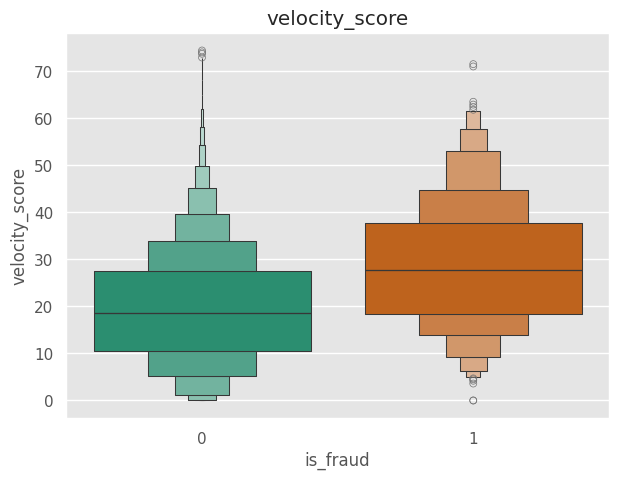

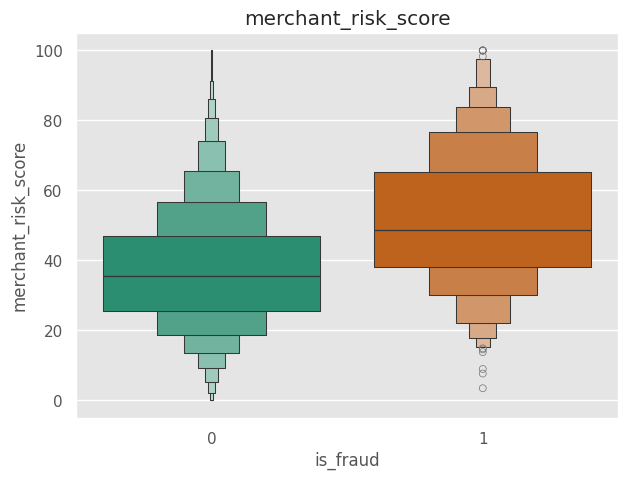

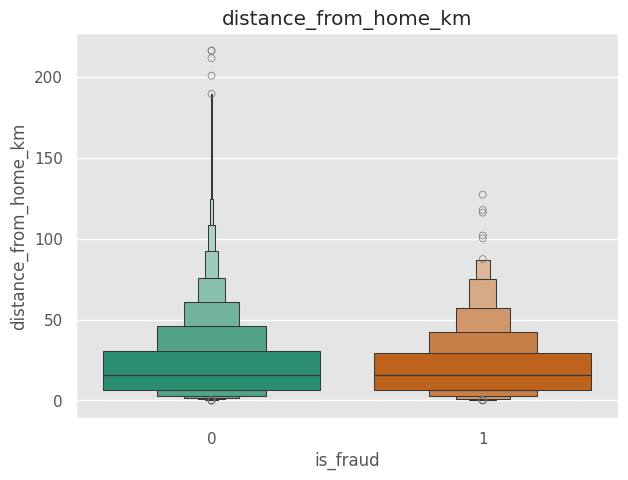

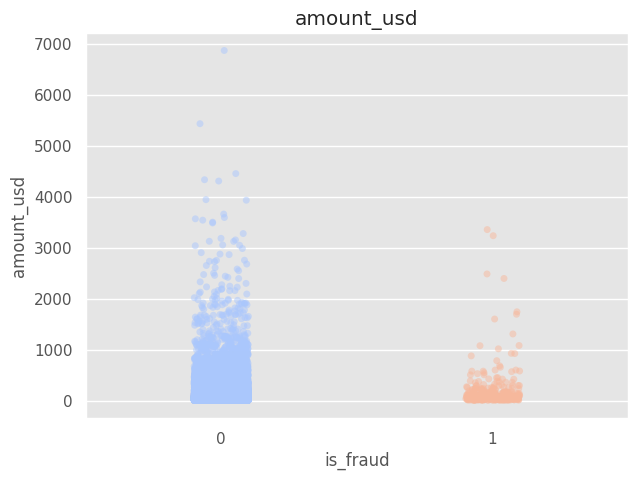

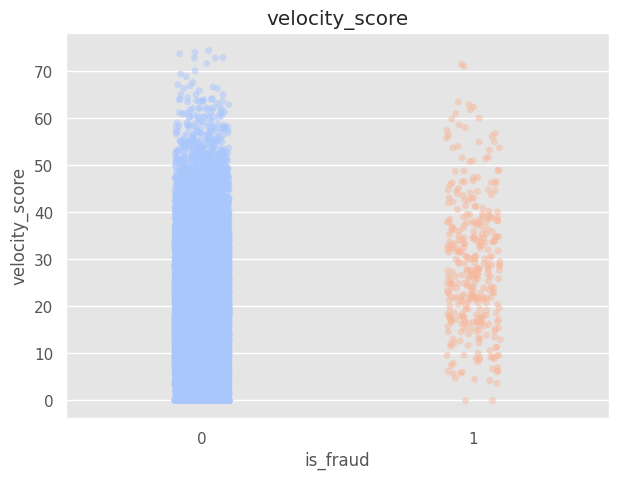

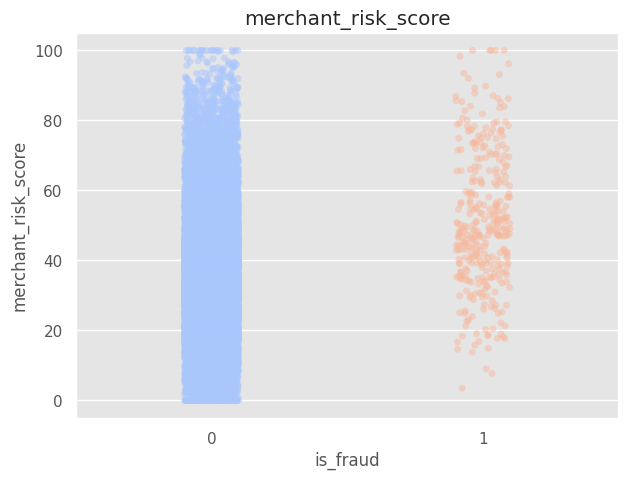

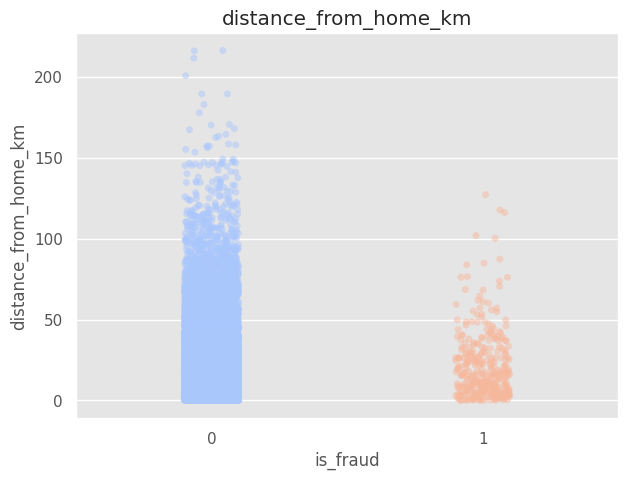

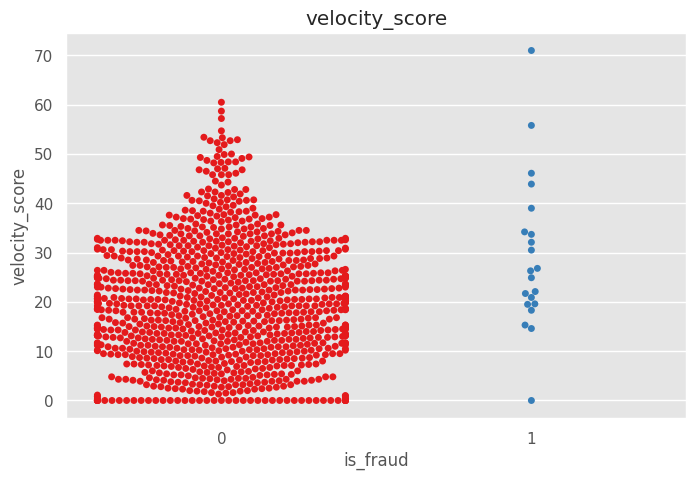

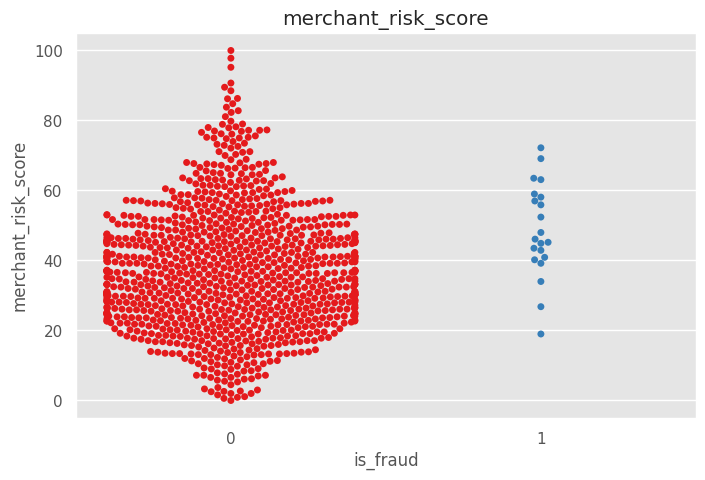

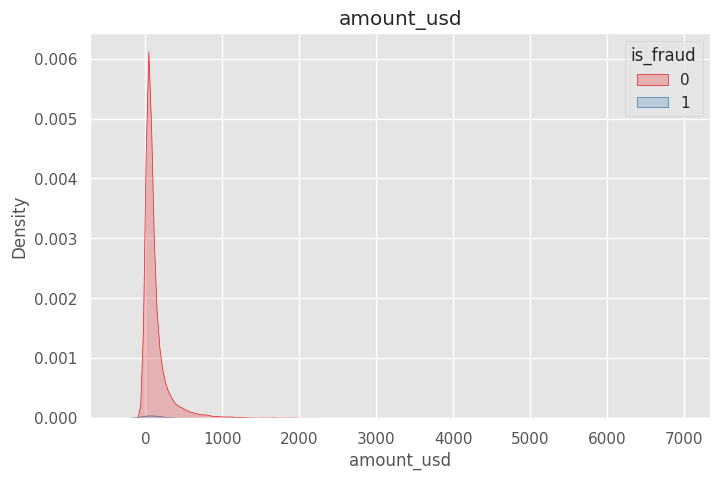

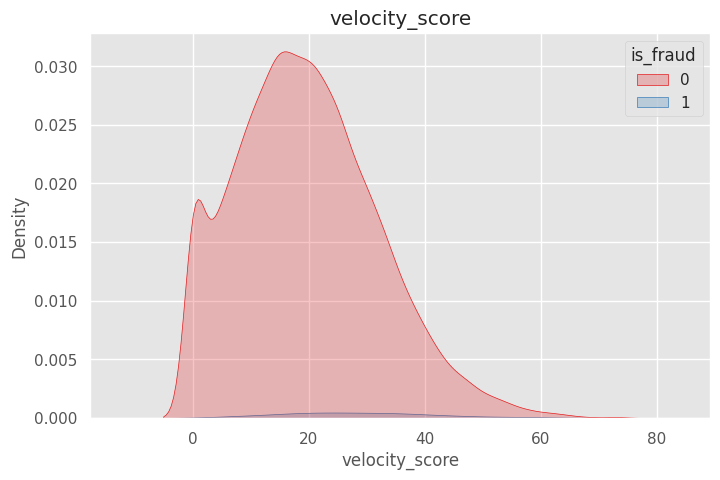

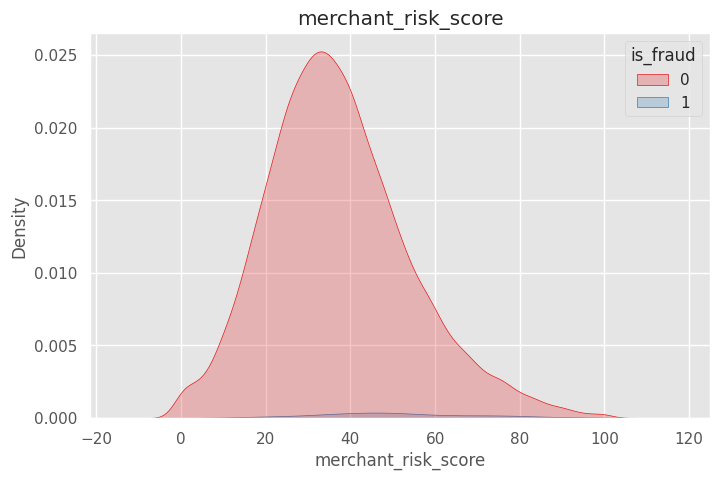

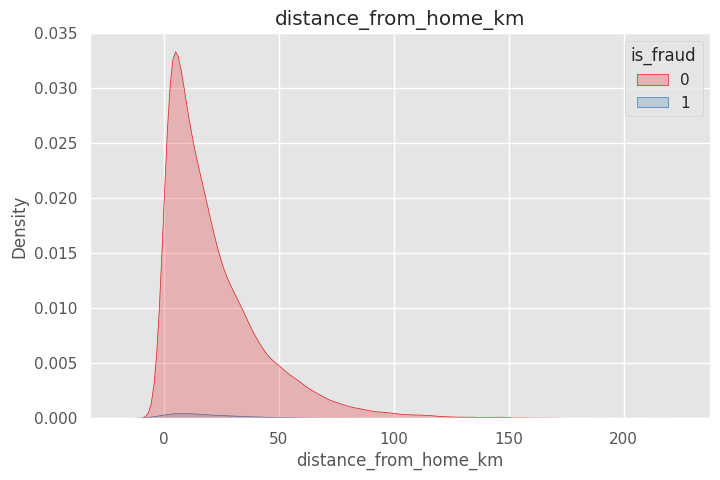

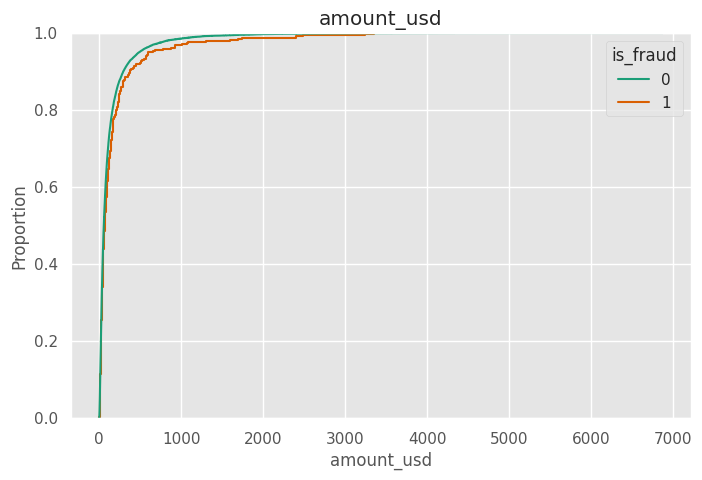

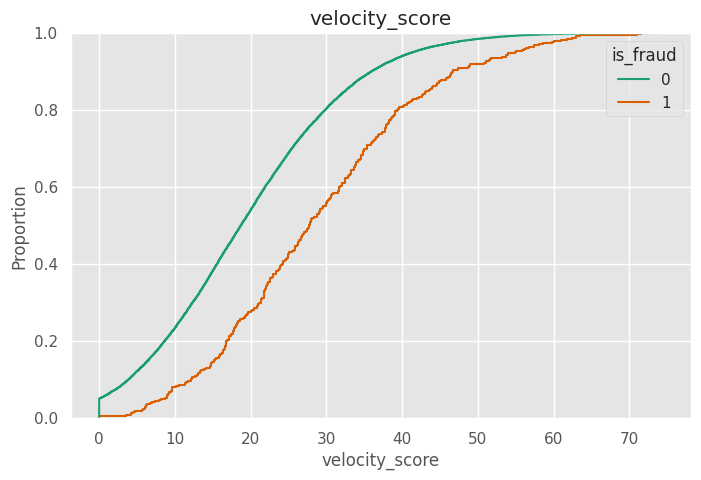

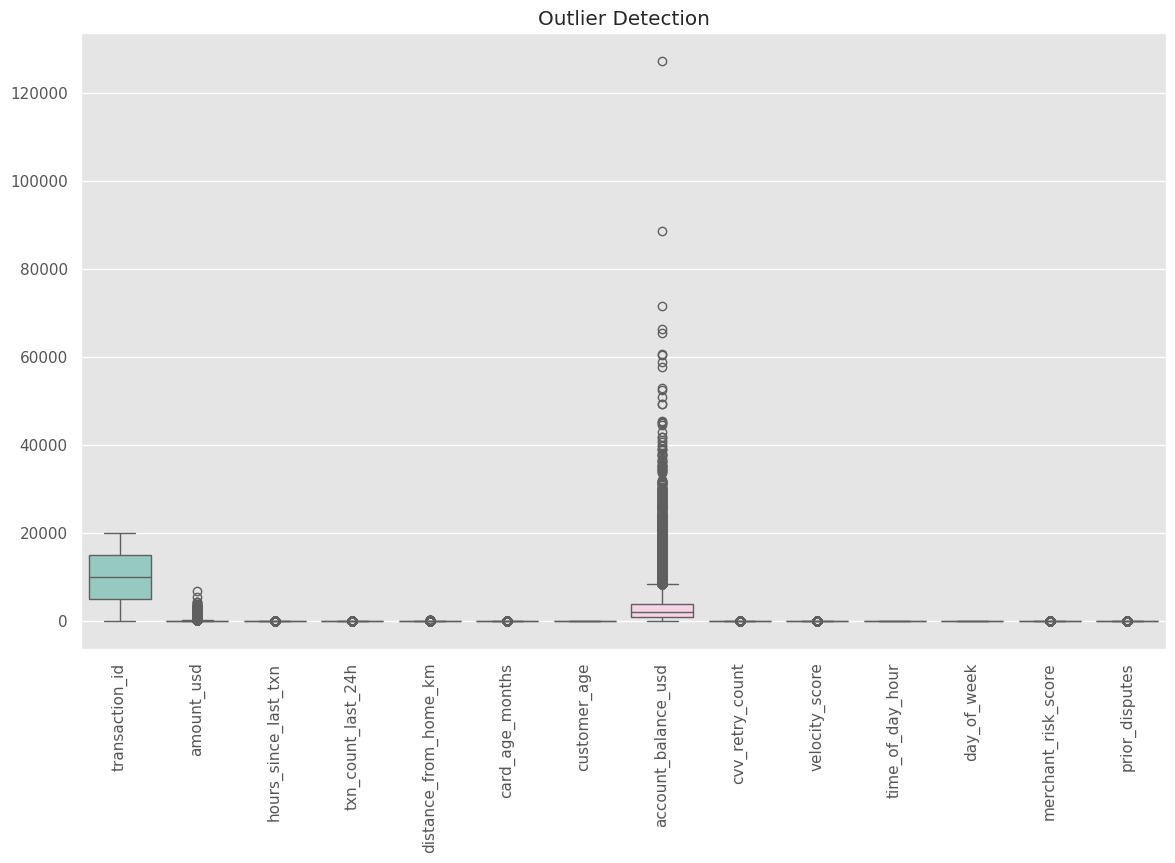

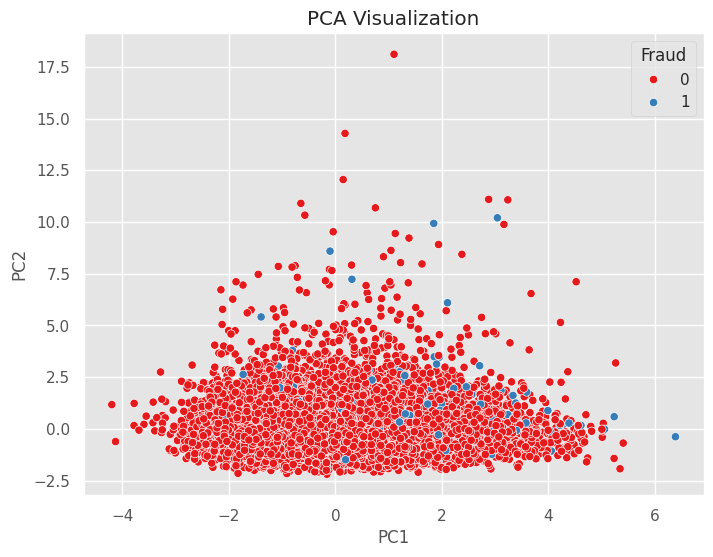

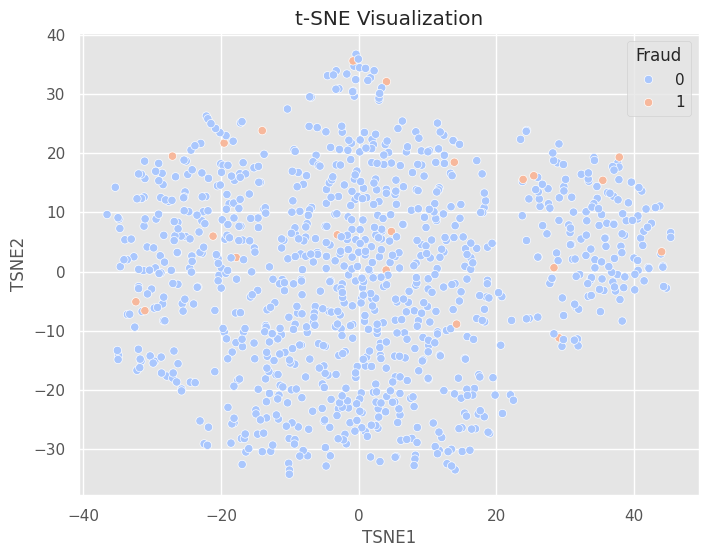

In [13]:
# ==========================================================
# PART 4 : ADVANCED VISUALIZATION
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

plt.style.use("ggplot")

# ==========================================================
# Numerical Columns
# ==========================================================

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if "is_fraud" in numeric_cols:
    numeric_cols.remove("is_fraud")

# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(18,12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap",fontsize=20)

plt.show()

# ==========================================================
# Correlation with Target
# ==========================================================

plt.figure(figsize=(8,10))

target_corr = corr["is_fraud"].sort_values()

target_corr.plot(
    kind="barh",
    color="darkcyan"
)

plt.title("Correlation with Fraud")

plt.show()

# ==========================================================
# Pairplot
# ==========================================================

sample = df.sample(min(500, len(df)), random_state=42)

pair_cols = [
    "amount_usd",
    "velocity_score",
    "merchant_risk_score",
    "account_balance_usd",
    "distance_from_home_km",
    "is_fraud"
]

sns.pairplot(
    sample[pair_cols],
    hue="is_fraud",
    palette="husl"
)

plt.show()

# ==========================================================
# Scatterplots
# ==========================================================

scatter_pairs = [

("amount_usd","velocity_score"),

("account_balance_usd","amount_usd"),

("merchant_risk_score","velocity_score"),

("customer_age","card_age_months"),

("distance_from_home_km","amount_usd")

]

for x,y in scatter_pairs:

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="is_fraud",
        palette="Set1",
        alpha=.7
    )

    plt.title(f"{x} vs {y}")

    plt.show()

# ==========================================================
# Hexbin
# ==========================================================

plt.figure(figsize=(8,6))

plt.hexbin(
    df["amount_usd"],
    df["account_balance_usd"],
    gridsize=30,
    cmap="inferno"
)

plt.colorbar()

plt.xlabel("Amount")

plt.ylabel("Balance")

plt.title("Hexbin Plot")

plt.show()

# ==========================================================
# Jointplots
# ==========================================================

sns.jointplot(
    data=df,
    x="amount_usd",
    y="velocity_score",
    kind="scatter",
    color="purple",
    height=7
)

plt.show()

sns.jointplot(
    data=df,
    x="merchant_risk_score",
    y="distance_from_home_km",
    kind="hex",
    cmap="viridis",
    height=7
)

plt.show()

# ==========================================================
# Violin Plot
# ==========================================================

violin_cols = [

"amount_usd",

"velocity_score",

"merchant_risk_score",

"distance_from_home_km"

]

for col in violin_cols:

    plt.figure(figsize=(7,5))

    sns.violinplot(
        data=df,
        x="is_fraud",
        y=col,
        palette="Set2"
    )

    plt.title(col)

    plt.show()

# ==========================================================
# Boxen Plot
# ==========================================================

for col in violin_cols:

    plt.figure(figsize=(7,5))

    sns.boxenplot(
        data=df,
        x="is_fraud",
        y=col,
        palette="Dark2"
    )

    plt.title(col)

    plt.show()

# ==========================================================
# Strip Plot
# ==========================================================

for col in violin_cols:

    plt.figure(figsize=(7,5))

    sns.stripplot(
        data=df,
        x="is_fraud",
        y=col,
        hue="is_fraud",
        palette="coolwarm",
        dodge=False,
        alpha=.5,
        legend=False
    )

    plt.title(col)

    plt.show()

# ==========================================================
# Swarm Plot
# ==========================================================

sample_swarm = df.sample(min(1000,len(df)),random_state=42)

for col in ["velocity_score","merchant_risk_score"]:

    plt.figure(figsize=(8,5))

    sns.swarmplot(
        data=sample_swarm,
        x="is_fraud",
        y=col,
        hue="is_fraud",
        palette="Set1",
        dodge=False,
        legend=False
    )

    plt.title(col)

    plt.show()

# ==========================================================
# KDE Plot
# ==========================================================

for col in violin_cols:

    plt.figure(figsize=(8,5))

    sns.kdeplot(
        data=df,
        x=col,
        hue="is_fraud",
        fill=True,
        palette="Set1"
    )

    plt.title(col)

    plt.show()

# ==========================================================
# ECDF Plot
# ==========================================================

for col in ["amount_usd","velocity_score"]:

    plt.figure(figsize=(8,5))

    sns.ecdfplot(
        data=df,
        x=col,
        hue="is_fraud",
        palette="Dark2"
    )

    plt.title(col)

    plt.show()

# ==========================================================
# Outlier Detection
# ==========================================================

plt.figure(figsize=(14,8))

sns.boxplot(
    data=df[numeric_cols],
    palette="Set3"
)

plt.xticks(rotation=90)

plt.title("Outlier Detection")

plt.show()

# ==========================================================
# PCA
# ==========================================================

features = df[numeric_cols].fillna(df[numeric_cols].median())

scaler = StandardScaler()

scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled)

pca_df = pd.DataFrame(pca_data,columns=["PC1","PC2"])

pca_df["Fraud"] = df["is_fraud"].values

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Fraud",
    palette="Set1"
)

plt.title("PCA Visualization")

plt.show()

# ==========================================================
# t-SNE
# ==========================================================

sample = df.sample(min(1000,len(df)),random_state=42)

X = sample[numeric_cols].fillna(sample[numeric_cols].median())

X = StandardScaler().fit_transform(X)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_result = tsne.fit_transform(X)

tsne_df = pd.DataFrame(tsne_result,columns=["TSNE1","TSNE2"])

tsne_df["Fraud"] = sample["is_fraud"].values

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Fraud",
    palette="coolwarm"
)

plt.title("t-SNE Visualization")

plt.show()

# ==========================================================
# END OF PART 4
# ==========================================================

## Features Engineering

In [14]:
# ==========================================================
# PART 5.1
# DATA PREPROCESSING
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Machine Learning
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==========================================================
# Dataset Shape
# ==========================================================

print("="*60)
print("Dataset Shape :", df.shape)
print("="*60)

# ==========================================================
# Remove Duplicate Rows
# ==========================================================

duplicates = df.duplicated().sum()
print("Duplicate Rows :", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates :", df.shape)

# ==========================================================
# Drop Transaction ID
# ==========================================================

if "transaction_id" in df.columns:
    df.drop(columns=["transaction_id"], inplace=True)

print("\nColumns Remaining")
print(df.columns)

# ==========================================================
# Target Variable
# ==========================================================

target = "is_fraud"

X = df.drop(columns=[target])
y = df[target]

print("\nFeature Shape :", X.shape)
print("Target Shape :", y.shape)

# ==========================================================
# Target Distribution
# ==========================================================

print("\nTarget Distribution")
print(y.value_counts())

print("\nTarget Percentage")

print((y.value_counts(normalize=True)*100).round(2))

# ==========================================================
# Numerical Columns
# ==========================================================

numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

print("\nNumerical Features")
print(numeric_features)

# ==========================================================
# Categorical Columns
# ==========================================================

categorical_features = X.select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

print("\nCategorical Features")
print(categorical_features)

# ==========================================================
# Train Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTrain Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

# ==========================================================
# Numerical Pipeline
# ==========================================================

numeric_transformer = Pipeline(

    steps=[

        ("imputer",
         SimpleImputer(strategy="median")),

        ("scaler",
         StandardScaler())

    ]

)

# ==========================================================
# Categorical Pipeline
# ==========================================================

categorical_transformer = Pipeline(

    steps=[

        ("imputer",
         SimpleImputer(strategy="most_frequent")),

        ("encoder",
         OneHotEncoder(handle_unknown="ignore"))

    ]

)

# ==========================================================
# Column Transformer
# ==========================================================

preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_transformer,

            numeric_features

        ),

        (

            "cat",

            categorical_transformer,

            categorical_features

        )

    ]

)

# ==========================================================
# Fit ONLY on Training Data
# ==========================================================

X_train_processed = preprocessor.fit_transform(X_train)

# ==========================================================
# Transform Test Data
# ==========================================================

X_test_processed = preprocessor.transform(X_test)

print("\nProcessed Train Shape")

print(X_train_processed.shape)

print("\nProcessed Test Shape")

print(X_test_processed.shape)

# ==========================================================
# Label Information
# ==========================================================

print("\nTraining Class Distribution")

print(y_train.value_counts())

print("\nTesting Class Distribution")

print(y_test.value_counts())

# ==========================================================
# Check Missing Values
# ==========================================================

print("\nMissing Values in Train")

print(X_train.isnull().sum().sum())

print("\nMissing Values in Test")

print(X_test.isnull().sum().sum())

# ==========================================================
# Data Leakage Check
# ==========================================================

print("\nData Leakage Prevention")

print("✔ Train/Test Split Completed Before Preprocessing")

print("✔ Imputer Fit Only On Training Data")

print("✔ Scaler Fit Only On Training Data")

print("✔ OneHotEncoder Fit Only On Training Data")

print("✔ Test Data Never Used During Training")

print("\nPreprocessing Completed Successfully!")

Dataset Shape : (20000, 26)
Duplicate Rows : 0
Shape After Removing Duplicates : (20000, 26)

Columns Remaining
Index(['amount_usd', 'merchant_category', 'card_type', 'auth_method',
       'channel', 'device_type', 'is_foreign_transaction',
       'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km',
       'card_age_months', 'customer_age', 'account_balance_usd',
       'is_new_merchant', 'used_vpn', 'ip_country_mismatch',
       'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score',
       'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt',
       'merchant_risk_score', 'prior_disputes', 'is_fraud'],
      dtype='object')

Feature Shape : (20000, 24)
Target Shape : (20000,)

Target Distribution
is_fraud
0    19661
1      339
Name: count, dtype: int64

Target Percentage
is_fraud
0    98.3
1     1.7
Name: proportion, dtype: float64

Numerical Features
['amount_usd', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_a

In [15]:
# ==========================================================
# PART 5.2A
# TRAIN MACHINE LEARNING MODELS
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import accuracy_score

# ==========================================================
# Dictionary to Store Models
# ==========================================================

models = {}

results = []

# ==========================================================
# Logistic Regression
# ==========================================================

print("="*60)
print("Training Logistic Regression")
print("="*60)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_processed, y_train)

pred = lr.predict(X_test_processed)

acc = accuracy_score(y_test, pred)

print("Accuracy :", round(acc*100,2),"%")

models["Logistic Regression"] = lr

results.append([
    "Logistic Regression",
    acc
])

# ==========================================================
# Decision Tree
# ==========================================================

print("="*60)
print("Training Decision Tree")
print("="*60)

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train_processed, y_train)

pred = dt.predict(X_test_processed)

acc = accuracy_score(y_test, pred)

print("Accuracy :", round(acc*100,2),"%")

models["Decision Tree"] = dt

results.append([
    "Decision Tree",
    acc
])

# ==========================================================
# Random Forest
# ==========================================================

print("="*60)
print("Training Random Forest")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_processed, y_train)

pred = rf.predict(X_test_processed)

acc = accuracy_score(y_test, pred)

print("Accuracy :", round(acc*100,2),"%")

models["Random Forest"] = rf

results.append([
    "Random Forest",
    acc
])

# ==========================================================
# Extra Trees
# ==========================================================

print("="*60)
print("Training Extra Trees")
print("="*60)

et = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train_processed, y_train)

pred = et.predict(X_test_processed)

acc = accuracy_score(y_test, pred)

print("Accuracy :", round(acc*100,2),"%")

models["Extra Trees"] = et

results.append([
    "Extra Trees",
    acc
])

# ==========================================================
# Gaussian Naive Bayes
# ==========================================================

print("="*60)
print("Training Gaussian Naive Bayes")
print("="*60)

gnb = GaussianNB()

# Convert sparse matrices if needed
X_train_nb = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_nb = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

gnb.fit(X_train_nb, y_train)

pred = gnb.predict(X_test_nb)

acc = accuracy_score(y_test, pred)

print("Accuracy :", round(acc*100,2),"%")

models["Gaussian Naive Bayes"] = gnb

results.append([
    "Gaussian Naive Bayes",
    acc
])

# ==========================================================
# Accuracy Table
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

results_df["Accuracy"] = (
    results_df["Accuracy"]*100
).round(2)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*70)
print("MODEL PERFORMANCE")
print("="*70)

display(results_df)

Training Logistic Regression
Accuracy : 98.47 %
Training Decision Tree
Accuracy : 97.08 %
Training Random Forest
Accuracy : 98.3 %
Training Extra Trees
Accuracy : 98.28 %
Training Gaussian Naive Bayes
Accuracy : 86.45 %


MODEL PERFORMANCE


,Model,Accuracy
0,Logistic Regression,98.48
2,Random Forest,98.30
3,Extra Trees,98.28
1,Decision Tree,97.08
4,Gaussian Naive Bayes,86.45


In [16]:
# ==========================================================
# PART 5.2B
# Remaining Machine Learning Models
# ==========================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# ==========================================================
# K-Nearest Neighbors
# ==========================================================

print("="*60)
print("Training KNN")
print("="*60)

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_processed, y_train)

pred = knn.predict(X_test_processed)

acc = accuracy_score(y_test, pred)

print("Accuracy :", round(acc*100,2), "%")

models["KNN"] = knn

results.append([
    "KNN",
    acc
])

# ==========================================================
# Support Vector Machine
# ==========================================================

print("="*60)
print("Training SVM")
print("="*60)

svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm.fit(X_train_processed, y_train)

pred = svm.predict(X_test_processed)

acc = accuracy_score(y_test, pred)

print("Accuracy :", round(acc*100,2), "%")

models["SVM"] = svm

results.append([
    "SVM",
    acc
])

# ==========================================================
# Gradient Boosting
# ==========================================================

print("="*60)
print("Training Gradient Boosting")
print("="*60)

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train_processed, y_train)

pred = gb.predict(X_test_processed)

acc = accuracy_score(y_test, pred)

print("Accuracy :", round(acc*100,2), "%")

models["Gradient Boosting"] = gb

results.append([
    "Gradient Boosting",
    acc
])

# ==========================================================
# AdaBoost
# ==========================================================

print("="*60)
print("Training AdaBoost")
print("="*60)

ada = AdaBoostClassifier(
    n_estimators=200,
    random_state=42
)

ada.fit(X_train_processed, y_train)

pred = ada.predict(X_test_processed)

acc = accuracy_score(y_test, pred)

print("Accuracy :", round(acc*100,2), "%")

models["AdaBoost"] = ada

results.append([
    "AdaBoost",
    acc
])

# ==========================================================
# XGBoost (Optional)
# ==========================================================

try:

    from xgboost import XGBClassifier

    print("="*60)
    print("Training XGBoost")
    print("="*60)

    xgb = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )

    xgb.fit(X_train_processed, y_train)

    pred = xgb.predict(X_test_processed)

    acc = accuracy_score(y_test, pred)

    print("Accuracy :", round(acc*100,2), "%")

    models["XGBoost"] = xgb

    results.append([
        "XGBoost",
        acc
    ])

except ImportError:

    print("\nXGBoost is not installed. Skipping...\n")

# ==========================================================
# Final Accuracy Comparison
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

results_df["Accuracy"] = (
    results_df["Accuracy"] * 100
).round(2)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)

display(results_df)

# ==========================================================
# Best Model
# ==========================================================

best_model = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy"]

print(f"\nBest Model : {best_model}")

print(f"Best Accuracy : {best_accuracy}%")

Training KNN
Accuracy : 98.3 %
Training SVM
Accuracy : 98.3 %
Training Gradient Boosting
Accuracy : 98.35 %
Training AdaBoost
Accuracy : 98.3 %
Training XGBoost
Accuracy : 98.42 %


FINAL MODEL PERFORMANCE


,Model,Accuracy
0,Logistic Regression,98.48
9,XGBoost,98.42
7,Gradient Boosting,98.35
6,SVM,98.30
2,Random Forest,98.30
5,KNN,98.30
8,AdaBoost,98.30
3,Extra Trees,98.28
1,Decision Tree,97.08
4,Gaussian Naive Bayes,86.45



Best Model : Logistic Regression
Best Accuracy : 98.48%
